In [151]:
from cosipy import COSILike
from cosipy.spacecraftfile import SpacecraftFile
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.util import fetch_wasabi_file
from histpy import Histogram

from scoords import SpacecraftFrame

from astropy.time import Time
import astropy.units as u
from astropy.coordinates import SkyCoord, Galactic

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from threeML import *
from threeML.io.package_data import get_path_of_data_file
from threeML.io.logging import silence_console_log
from astromodels import Parameter
from threeML.minimizer.minimization import CannotComputeCovariance

from jupyterthemes import jtplot
jtplot.style(context="talk", fscale=1, ticks=True, grid=False)
set_threeML_style()
silence_warnings()

from scipy.integrate import quad

import matplotlib.ticker as mticker

from pathlib import Path

import os

%matplotlib inline


In [152]:
data_path = Path("/Users/parshadkp/Software/COSI_Data/")

In [153]:
sc_orientation = SpacecraftFile.parse_from_file(data_path /"DC3_Files/DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori") #DC3

In [154]:
dr = str(data_path / "DC3_Files/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse_nside8.area.good_chunks.h5") # DC3

In [155]:
multiplier_4151 = 1
multiplier_1068 = 1
exposure_4151 = multiplier_4151 * 3
exposure_1068 = multiplier_1068 * 3

# Source Model Plots

## Cutoff Power Law (Thermal)

#### NGC 4151 (200 keV)

In [156]:
K_inj = 0.15*multiplier_4151 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 200. * u.keV
index_inj = -1.75

spectrum_inj_ec200 = Cutoff_powerlaw()

spectrum_inj_ec200.K.value = K_inj.value
spectrum_inj_ec200.piv.value = piv_inj.value
spectrum_inj_ec200.xc.value = xc_inj.value
spectrum_inj_ec200.index.value = index_inj

spectrum_inj_ec200.K.unit = K_inj.unit
spectrum_inj_ec200.piv.unit = piv_inj.unit
spectrum_inj_ec200.xc.unit = xc_inj.unit

#### NGC 4151 (1000 keV)

In [157]:
K_inj = 0.15*multiplier_4151 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 1000. * u.keV
index_inj = -1.75

spectrum_inj_ec1000 = Cutoff_powerlaw()

spectrum_inj_ec1000.K.value = K_inj.value
spectrum_inj_ec1000.piv.value = piv_inj.value
spectrum_inj_ec1000.xc.value = xc_inj.value
spectrum_inj_ec1000.index.value = index_inj

spectrum_inj_ec1000.K.unit = K_inj.unit
spectrum_inj_ec1000.piv.unit = piv_inj.unit
spectrum_inj_ec1000.xc.unit = xc_inj.unit

#### NGC 1068 (200 keV)

In [158]:
K_inj = 3.1e-1*multiplier_1068 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 200. * u.keV
index_inj = -1.92

spectrum_inj_1068 = Cutoff_powerlaw()

spectrum_inj_1068.K.value = K_inj.value
spectrum_inj_1068.piv.value = piv_inj.value
spectrum_inj_1068.xc.value = xc_inj.value
spectrum_inj_1068.index.value = index_inj

spectrum_inj_1068.K.unit = K_inj.unit
spectrum_inj_1068.piv.unit = piv_inj.unit
spectrum_inj_1068.xc.unit = xc_inj.unit

# Power law tail (Non-thermal)

#### NGC 4151 (200 keV)

In [159]:
# K_inj = 0.1*spectrum_inj_ec200.evaluate_at(1000) / u.cm / u.cm / u.s / u.keV
# piv_inj = 1000. * u.keV

K_inj = 0.15*spectrum_inj_ec200.evaluate_at(200) / u.cm / u.cm / u.s / u.keV
piv_inj = 200. * u.keV
index_inj = -3.8

spectrum_inj_ec200_PL = Powerlaw()

spectrum_inj_ec200_PL.K.value = K_inj.value
spectrum_inj_ec200_PL.piv.value = piv_inj.value
spectrum_inj_ec200_PL.index.value = index_inj

spectrum_inj_ec200_PL.K.unit = K_inj.unit
spectrum_inj_ec200_PL.piv.unit = piv_inj.unit

spectrum_inj_ec200_total = spectrum_inj_ec200 + spectrum_inj_ec200_PL

print("K_inj: ", K_inj)
print(spectrum_inj_ec200.evaluate_at(200))
print(spectrum_inj_ec200_PL.evaluate_at(200))
print("="*40)
print("Linking ratio", spectrum_inj_ec200_PL.evaluate_at(200)/spectrum_inj_ec200.evaluate_at(200))
print("="*40)
flux_th, _ = quad(spectrum_inj_ec200.evaluate_at, 200.0, 5000.0)
flux_nth, _ = quad(spectrum_inj_ec200_PL.evaluate_at, 200.0, 5000.0)
print("Non-thermal flux: ", flux_nth)
print("Total flux: ", flux_th + flux_nth)
print("Thermal - Non-thermal Flux Ratio: ", flux_th/flux_nth)
print("Non-thermal percentage: ", flux_nth/(flux_th + flux_nth))

energy_flux_kev, energy_flux_kev_err = quad(
    lambda E: E * (spectrum_inj_ec200 + spectrum_inj_ec200_PL).evaluate_at(E),
    200.0,
    5000.0,
)

energy_flux = (energy_flux_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
energy_flux_err = (energy_flux_kev_err * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)

print("energy_flux: ", energy_flux)
print("energy_flux_err: ", energy_flux_err)

K_inj_at_fit_pivot = (
    spectrum_inj_ec200.K.value
    * (200.0 / spectrum_inj_ec200.piv.value) ** spectrum_inj_ec200.index.value
)

print(K_inj_at_fit_pivot)

K_inj:  7.781898174481237e-07 1 / (keV s cm2)
5.187932116320825e-06
7.781898174481238e-07
Linking ratio 0.15000000000000002
Non-thermal flux:  5.557821482750225e-05
Total flux:  0.0005129574744048934
Thermal - Non-thermal Flux Ratio:  8.229470143957595
Non-thermal percentage:  0.10834858170646838
energy_flux:  2.501812122050731e-10 erg / (s cm2)
energy_flux_err:  3.5597785328400256e-19 erg / (s cm2)
1.4102261599073975e-05


#### NGC 4151 (1000 keV)

In [160]:
# K_inj = (spectrum_inj_ec1000.evaluate_at(3000)) / u.cm / u.cm / u.s / u.keV
K_inj = spectrum_inj_ec200_PL.evaluate_at(200) / u.cm / u.cm / u.s / u.keV
piv_inj = 200. * u.keV
index_inj = -3.8

spectrum_inj_ec1000_PL = Powerlaw()

spectrum_inj_ec1000_PL.K.value = K_inj.value
spectrum_inj_ec1000_PL.piv.value = piv_inj.value
spectrum_inj_ec1000_PL.index.value = index_inj

spectrum_inj_ec1000_PL.K.unit = K_inj.unit
spectrum_inj_ec1000_PL.piv.unit = piv_inj.unit

spectrum_inj_ec1000_total = spectrum_inj_ec1000 + spectrum_inj_ec1000_PL

print("K_inj: ", K_inj)
print(spectrum_inj_ec1000.evaluate_at(200))
print(spectrum_inj_ec1000_PL.evaluate_at(200))
print("="*40)
print("Linking ratio", spectrum_inj_ec1000_PL.evaluate_at(200)/spectrum_inj_ec1000.evaluate_at(200))
print("="*40)
flux_th, _ = quad(spectrum_inj_ec1000.evaluate_at, 200.0, 5000.0)
flux_nth, _ = quad(spectrum_inj_ec1000_PL.evaluate_at, 200.0, 5000.0)
print("Non-thermal flux: ", flux_nth)
print("Total flux: ", flux_th + flux_nth)
print("Thermal - Non-thermal Flux Ratio: ", flux_th/flux_nth)
print("Non-thermal percentage: ", flux_nth/(flux_th + flux_nth))

energy_flux_kev, energy_flux_kev_err = quad(
    lambda E: E * (spectrum_inj_ec1000 + spectrum_inj_ec1000_PL).evaluate_at(E),
    200.0,
    5000.0,
)

energy_flux = (energy_flux_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
energy_flux_err = (energy_flux_kev_err * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)

print("energy_flux: ", energy_flux)
print("energy_flux_err: ", energy_flux_err)

K_inj_at_fit_pivot = (
    spectrum_inj_ec1000.K.value
    * (200.0 / spectrum_inj_ec1000.piv.value) ** spectrum_inj_ec1000.index.value
)

print(K_inj_at_fit_pivot)

K_inj:  7.781898174481238e-07 1 / (keV s cm2)
1.1545955259112548e-05
7.781898174481238e-07
Linking ratio 0.06739934461758319
Non-thermal flux:  5.557821482750225e-05
Total flux:  0.0019511105578609968
Thermal - Non-thermal Flux Ratio:  34.10567160022405
Non-thermal percentage:  0.028485425699521952
energy_flux:  1.4468976076756429e-09 erg / (s cm2)
energy_flux_err:  2.5400983250747964e-19 erg / (s cm2)
1.4102261599073975e-05


#### NGC 1068 (200 keV)

In [161]:
# K_inj = 0.1*((3.1e-1)*100) / u.cm / u.cm / u.s / u.keV
K_inj = 0.15*spectrum_inj_1068.evaluate_at(200) / u.cm / u.cm / u.s / u.keV
piv_inj = 200. * u.keV
index_inj = -3.8

spectrum_inj_1068_PL = Powerlaw()

spectrum_inj_1068_PL.K.value = K_inj.value
spectrum_inj_1068_PL.piv.value = piv_inj.value
spectrum_inj_1068_PL.index.value = index_inj

spectrum_inj_1068_PL.K.unit = K_inj.unit
spectrum_inj_1068_PL.piv.unit = piv_inj.unit

spectrum_inj_1068_total = spectrum_inj_1068 + spectrum_inj_1068_PL

print(spectrum_inj_1068.evaluate_at(200))
print(spectrum_inj_1068_PL.evaluate_at(200))
print("="*40)
print("Linking ratio", spectrum_inj_1068_PL.evaluate_at(200)/spectrum_inj_1068.evaluate_at(200))
print("="*40)
flux_th, _ = quad(spectrum_inj_1068.evaluate_at, 200.0, 5000.0)
flux_nth, _ = quad(spectrum_inj_1068_PL.evaluate_at, 200.0, 5000.0)
print("Non-thermal flux: ", flux_nth)
print("Total flux: ", flux_th + flux_nth)
print("Thermal - Non-thermal Flux Ratio: ", flux_th/flux_nth)
print("Non-thermal percentage: ", flux_nth/(flux_th + flux_nth))

energy_flux_kev, energy_flux_kev_err = quad(
    lambda E: E * (spectrum_inj_1068 + spectrum_inj_1068_PL).evaluate_at(E),
    200.0,
    5000.0,
)

energy_flux = (energy_flux_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
energy_flux_err = (energy_flux_kev_err * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)

print("energy_flux: ", energy_flux)
print("energy_flux_err: ", energy_flux_err)

4.356017544341019e-06
6.534026316511528e-07
Linking ratio 0.15
Non-thermal flux:  4.6665930363685256e-05
Total flux:  0.00040815881601294606
Thermal - Non-thermal Flux Ratio:  7.7463983431169146
Non-thermal percentage:  0.11433277570612391
energy_flux:  1.957889381729402e-10 erg / (s cm2)
energy_flux_err:  3.566395272794118e-19 erg / (s cm2)


In [58]:
# energy = np.geomspace(200*u.keV,5*u.MeV).to_value(u.keV)
# energy = np.geomspace(200*u.keV,5*u.MeV).to_value(u.keV)
energy = np.geomspace(200*u.keV,5*u.MeV).to_value(u.keV)

flux_inj_ec200 = np.zeros_like(energy)
flux_inj_ec1000 = np.zeros_like(energy)
flux_inj_1068 = np.zeros_like(energy)
flux_inj_ec200_PL = np.zeros_like(energy)
flux_inj_ec1000_PL = np.zeros_like(energy)
flux_inj_1068_PL = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux_inj_ec1000[i] = spectrum_inj_ec1000.evaluate_at(e)
    flux_inj_ec200[i] = spectrum_inj_ec200.evaluate_at(e)
    flux_inj_1068[i] = spectrum_inj_1068.evaluate_at(e)
    flux_inj_ec200_PL[i] = spectrum_inj_ec200_PL.evaluate_at(e)
    flux_inj_ec1000_PL[i] = spectrum_inj_ec1000_PL.evaluate_at(e)
    flux_inj_1068_PL[i] = spectrum_inj_1068_PL.evaluate_at(e)

Plot the fitted and injected spectra

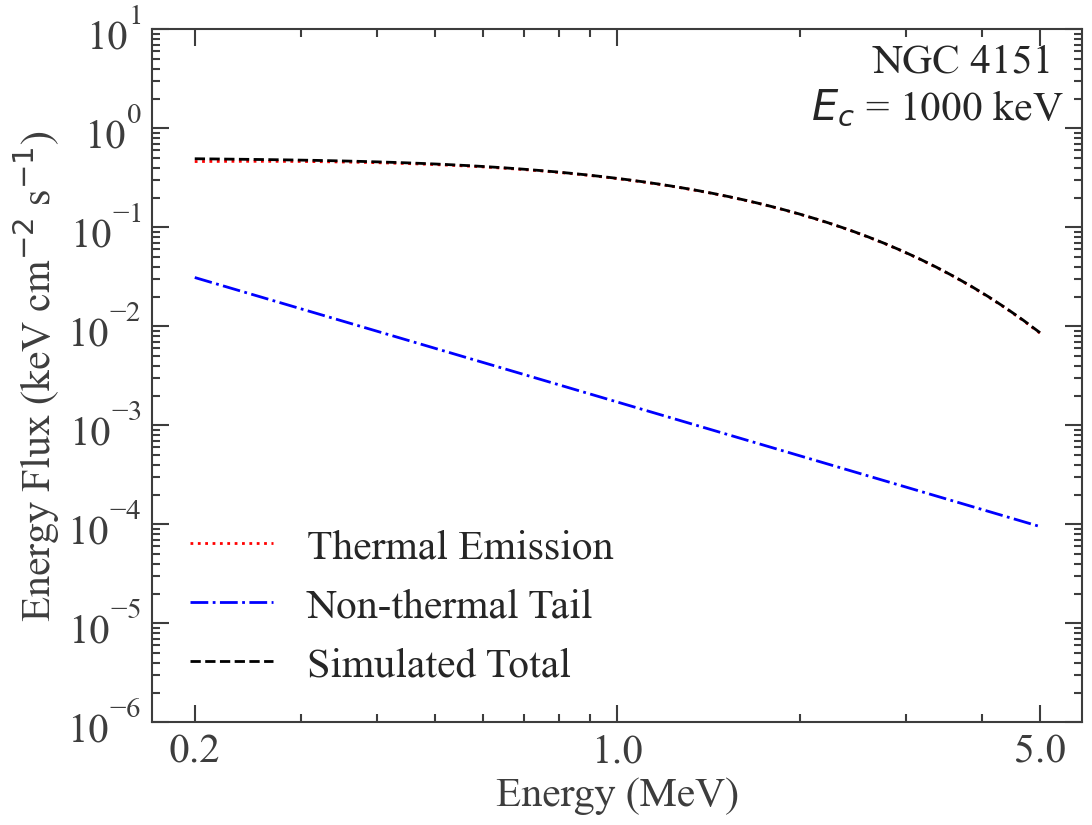

In [15]:
FONT_SIZE=30
plt.rcParams['agg.path.chunksize'] = 10000

plt.rcParams.update({'font.size': FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams.update({
    'font.weight': '550',
    'axes.titleweight': '550',
    'axes.labelweight': '550'
})

fig, ax = plt.subplots(figsize=(12, 9))

ax.xaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', top='on', pad=8, labelsize=FONT_SIZE)
ax.xaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', top='on', pad=8)
ax.yaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', right='on', pad=8, labelsize=FONT_SIZE)
ax.yaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', right='on', pad=8)

ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)

# # 200 keV cutoff
# text = 'NGC 4151 \n $E_{c}$ = 200 keV'
# total_flux_ec200 = flux_inj_ec200 + flux_inj_ec200_PL
# ax.plot(energy, energy*energy*flux_inj_ec200, color = 'red', ls = ":", label = "Thermal Emission")
# ax.plot(energy, energy*energy*flux_inj_ec200_PL, color = 'blue', ls = "-.", label = "Non-thermal Tail")
# ax.plot(energy, energy*energy*total_flux_ec200, color = 'black', ls = "--", label = "Simulated Total")
# ax.set_ylim(1e-6, 10)
# ax.text(
#     0.98, 0.98,
#     text,
#     transform=ax.transAxes,
#     ha='right', va='top',
#     fontsize=FONT_SIZE,
#     fontweight='550'
# )
# save_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC/Plots/NGC4151_TH_NTH_EC200.pdf"

# # 1000 keV cutoff
text = 'NGC 4151 \n $E_{c}$ = 1000 keV'
total_flux_ec1000 = flux_inj_ec1000 + flux_inj_ec1000_PL
ax.plot(energy, energy*energy*flux_inj_ec1000, color = 'red', ls = ":", label = "Thermal Emission")
ax.plot(energy, energy*energy*flux_inj_ec1000_PL, color = 'blue', ls = "-.", label = "Non-thermal Tail")
ax.plot(energy, energy*energy*total_flux_ec1000, color = 'black', ls = "--", label = "Simulated Total")
ax.set_ylim(1e-6, 10)
ax.text(
    0.98, 0.98,
    text,
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)
save_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC/Plots/NGC4151_TH_NTH_EC1000.pdf"

# # # NGC 1068
# text = 'NGC 1068 \n $E_c$ = 200 keV'
# total_flux_1068 = flux_inj_1068 + flux_inj_1068_PL
# ax.plot(energy, energy*energy*flux_inj_1068, color = 'red', ls = ":", label = "Thermal Emission")
# ax.plot(energy, energy*energy*flux_inj_1068_PL, color = 'blue', ls = "-.", label = "Non-thermal Tail")
# ax.plot(energy, energy*energy*total_flux_1068, color = 'black', ls = "--", label = "Simulated Total")
# ax.set_ylim(1e-6, 10)
# ax.text(
#     0.98, 0.98,
#     text,
#     transform=ax.transAxes,
#     ha='right', va='top',
#     fontsize=FONT_SIZE,
#     fontweight='550'
# )
# save_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC/Plots/NGC1068_TH_NTH_EC200.pdf"

ax.set_xscale("log")
ax.set_yscale("log")

ax.xaxis.set_major_locator(mticker.FixedLocator([200, 1000, 5000]))
ax.xaxis.set_major_formatter(
    mticker.FixedFormatter(["0.2", "1.0", "5.0"])
)

ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.set_ylabel(r"Energy Flux (keV cm$^{-2}$ s$^{-1}$)", fontsize=FONT_SIZE)

ax.legend(fontsize=FONT_SIZE, loc='lower left', frameon=False)

# plt.savefig(save_path)

# Spectral Fitting

In [265]:
bat_rsp_ec200 = "/Users/parshadkp/Software/COSI_Data/AGN_Data/XRay/swiftbat_survey_full.rsp"
bat_pha_ec200 = "/Users/parshadkp/Software/COSI_Data/AGN_Data/XRay/SWIFT_J1210.5+3924_resp.pha"

bat_rsp_ec1000 = data_path/"AGN_Data/XRay/Simulations/BAT_157m_swiftbat_survey_full_157m.rsp"
bat_pha_ec1000 = data_path/"AGN_Data/XRay/Simulations/simulate_bat_ec_1000_gamma_1dot75.pha"

bat_ec200 = OGIPLike("BAT", observation=bat_pha_ec200, response=bat_rsp_ec200)
bat_ec1000 = OGIPLike("BAT", observation=bat_pha_ec1000, response=bat_rsp_ec1000)

bat_ec200.set_active_measurements("40-200")
bat_ec1000.set_active_measurements("40-200")

# bat_ec200.view_count_spectrum()
# bat_ec1000.view_count_spectrum()

12:02:01 INFO      Auto-probed noise models:                                                    ]8;id=197561;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=961836;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#486\486]8;;\

         INFO      - observation: gaussian                                                      ]8;id=63371;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=210802;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#487\487]8;;\

         INFO      - background: None                                                           ]8;id=503684;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=134925;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#488\488]8;;\

         INFO      Auto-probed noise models:                                                    ]8;id=693813;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=348909;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#486\486]8;;\

         INFO      - observation: gaussian                                                      ]8;id=289559;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=521404;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#487\487]8;;\

         INFO      - background: None                                                           ]8;id=991208;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=676889;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#488\488]8;;\

         INFO      Range 40-200 translates to channels 3-8                                     ]8;id=701479;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=74341;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#1237\1237]8;;\

         INFO      Range 40-200 translates to channels 3-8                                     ]8;id=905368;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=254021;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#1237\1237]8;;\

In [266]:
# NGC4151_ec200 = Histogram.open(data_path/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec200_DC3_COSI_cpl_pl.hdf5")*multiplier_4151
# bkg = Histogram.open(data_path /  "DC4_Files/Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck_NGC4151_TimeCut.hdf5")*multiplier_4151
# NGC4151_ec200_bkg = Histogram.open(data_path/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec200_DC4_COSI_cpl_pl_TimeCutBkg.hdf5")*multiplier_4151

NGC4151_ec200 = Histogram.open(data_path/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec200_DC3_COSI_cpl.hdf5")*multiplier_4151
bkg = Histogram.open(data_path /  "DC4_Files/Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck_NGC4151_TimeCut.hdf5")*multiplier_4151
NGC4151_ec200_bkg = Histogram.open(data_path/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec200_DC4_COSI_cpl_TimeCutBkg.hdf5")*multiplier_4151

# full_bkg = Histogram.open(data_path /  "DC4_Files/Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck.hdf5")*multiplier_4151

In [267]:
# NGC4151_ec1000 = Histogram.open(data_path/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec1000_DC3_COSI_cpl_pl.hdf5")*multiplier_4151
# NGC4151_ec1000_bkg = Histogram.open(data_path/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec1000_DC4_COSI_cpl_pl_TimeCutBkg.hdf5")*multiplier_4151

NGC4151_ec1000 = Histogram.open(data_path/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec1000_DC3_COSI_cpl.hdf5")*multiplier_4151
NGC4151_ec1000_bkg = Histogram.open(data_path/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec1000_DC4_COSI_cpl_TimeCutBkg.hdf5")*multiplier_4151

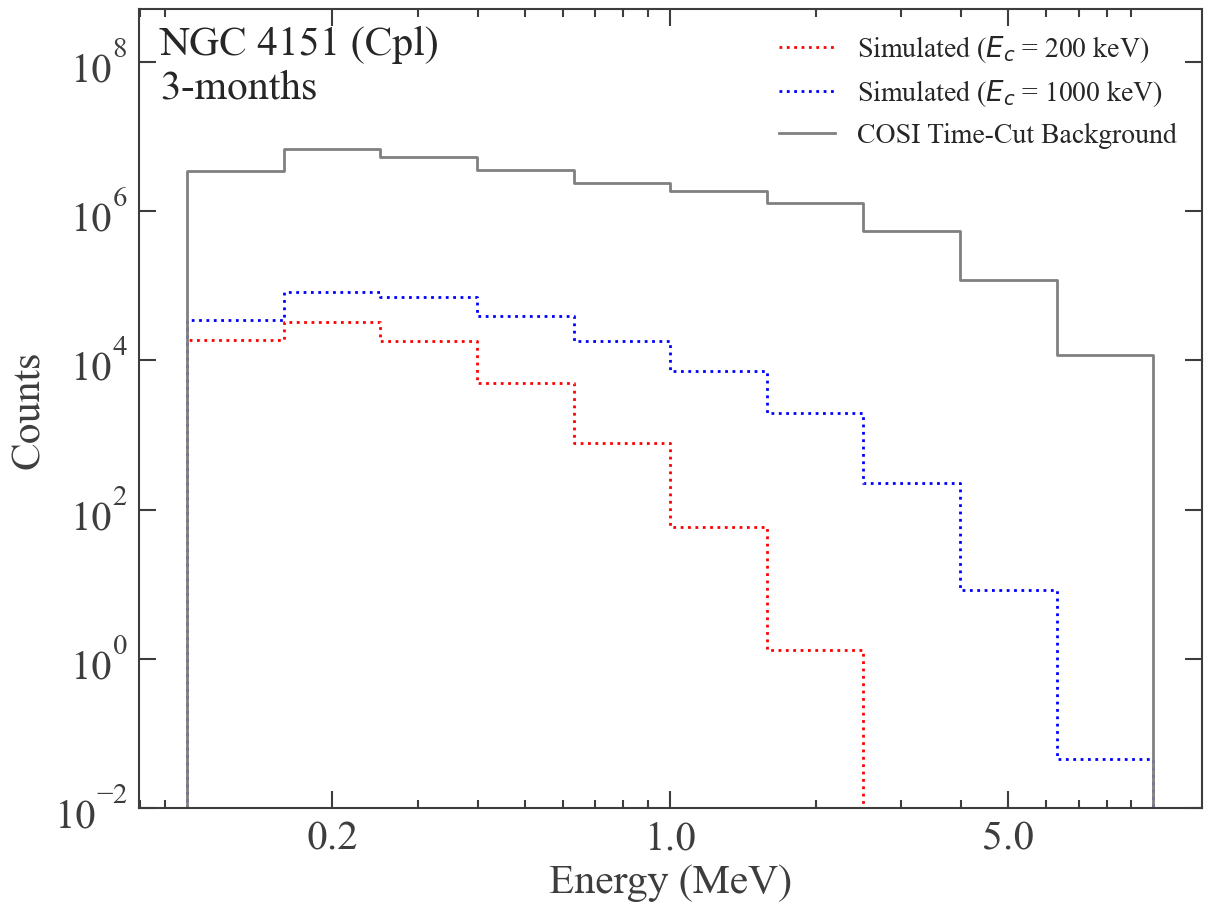

In [197]:
FONT_SIZE=30
plt.rcParams['agg.path.chunksize'] = 10000

plt.rcParams.update({'font.size': FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams.update({
    'font.weight': '550',
    'axes.titleweight': '550',
    'axes.labelweight': '550'
})

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)

ax.xaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', top='on', pad=8, labelsize=FONT_SIZE)
ax.xaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', top='on', pad=8)
ax.yaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', right='on', pad=8, labelsize=FONT_SIZE)
ax.yaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', right='on', pad=8)

ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)

NGC4151_ec200.project("Em").draw(ax, label="Simulated ($E_c$ = 200 keV)", color="red", linestyle="dotted")
NGC4151_ec1000.project("Em").draw(ax, label="Simulated ($E_c$ = 1000 keV)", color="blue", linestyle="dotted")
bkg.project("Em").draw(ax, label="COSI Time-Cut Background", color="grey")
# full_bkg.project("Em").draw(ax, label="DC4 Full Background", color="black", linestyle="dashdot")
# NGC4151_ec200_bkg.project("Em").draw(ax, label="NGC 4151 Model ($E_c$ = 200 keV) + Background", linestyle='dashdot', color="red")
# NGC4151_ec1000_bkg.project("Em").draw(ax, label="NGC 4151 Model ($E_c$ = 1000 keV) + Background", linestyle='dashdot', color="blue")

text = f'NGC 4151 (Cpl) \n{exposure_4151}-months'
ax.text(
    0.02, 0.98,
    text,
    transform=ax.transAxes,
    ha='left', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)

# ax.set_xlim(180, 5500)
ax.set_yscale("log")
ax.set_xscale("log")

ax.set_ylabel("Counts", fontsize=FONT_SIZE)
ax.set_ylim(1e-2, 5e8)

ax.xaxis.set_major_locator(mticker.FixedLocator([200, 1000, 5000]))
ax.xaxis.set_major_formatter(
    mticker.FixedFormatter(["0.2", "1.0", "5.0"])
)

ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.legend(fontsize=20, loc='upper right', frameon=False)

save_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC/Plots/NGC4151_Cpl_Counts_200_1000_3Months.pdf"
plt.savefig(save_path)

Define the path to the detector response

## Perform spectral fit

Set background parameter, which is used to fit the amplitude of the background, and instantiate the COSI 3ML plugin

In [268]:
bkg_par = Parameter("background_cosi",                                         # background parameter
                     1,                                                        # initial value of parameter
                     min_value=0,                                              # minimum value of parameter
                     max_value=5,                                              # maximum value of parameter
                     delta=0.05,                                               # initial step used by fitting engine
                     desc="Background parameter for cosi")

bkg_par_ec1000 = Parameter("background_cosi_ec1000",                           # background parameter
                     1,                                                        # initial value of parameter
                     min_value=0,                                              # minimum value of parameter
                     max_value=5,                                              # maximum value of parameter
                     delta=0.05,                                               # initial step used by fitting engine
                     desc="Background parameter for cosi")

cosi = COSILike("cosi",                                                        # COSI 3ML plugin
                 dr = dr,                                                      # detector response
                 data = NGC4151_ec200_bkg.project('Em', 'Phi', 'PsiChi'),   # data (source+background)
                 bkg = bkg.project('Em', 'Phi', 'PsiChi'),         # background model 
                 sc_orientation = sc_orientation,                              # spacecraft orientation
                 nuisance_param = bkg_par,                                     # background parameter
                 earth_occ = True)                                             # Option to account for Earth occultation

cosi_ec1000 = COSILike("cosi",                                                        # COSI 3ML plugin
                 dr = dr,                                                      # detector response
                 data = NGC4151_ec1000_bkg.project('Em', 'Phi', 'PsiChi'),   # data (source+background)
                 bkg = bkg.project('Em', 'Phi', 'PsiChi'),         # background model 
                 sc_orientation = sc_orientation,                              # spacecraft orientation
                 nuisance_param = bkg_par_ec1000,                                     # background parameter
                 earth_occ = True)                                             # Option to account for Earth occultation

### Powerlaw with energy cutoff fit

In [269]:
l=155.07
b=75.06

# Give it some harsher initial guesses
K = 1e-5 / u.cm / u.cm / u.s / u.keV
piv = 200. * u.keV
xc = 100. * u.keV
index = -1.75

spectrum_cpl = Cutoff_powerlaw()

spectrum_cpl.K.value = K.value
spectrum_cpl.piv.value = piv.value
spectrum_cpl.xc.value = xc.value
spectrum_cpl.index.value = index
# spectrum_cpl.index.fix = True

# Harsher Parameters
spectrum_cpl.K.min_value = 1e-8
spectrum_cpl.K.max_value = 1e-2
spectrum_cpl.xc.min_value = 100 # keep these relatively the same
spectrum_cpl.xc.max_value = 10000 # change to 1000
spectrum_cpl.index.min_value = -3 # change to -3.5 to sample lower, larger values (-5, 5)
spectrum_cpl.index.max_value = 1

# spectrum_cpl.K.delta = 0.05
# spectrum_cpl.xc.delta = 10
# spectrum_cpl.index.delta = 0.15

spectrum_cpl.K.unit = K.unit
spectrum_cpl.piv.unit = piv.unit
spectrum_cpl.xc.unit = xc.unit

source1 = PointSource("source1",                     # Name of source (arbitrary, but needs to be unique)
                     l = l,                        # Longitude (deg)
                     b = b,                        # Latitude (deg)
                     spectral_shape = spectrum_cpl)    # Spectral model

In [270]:
l=155.07
b=75.06

# Give it some harsher initial guesses
K = 1e-5 / u.cm / u.cm / u.s / u.keV
piv = 200. * u.keV
xc = 1000. * u.keV
index = -1.75

spectrum_cpl_ec1000 = Cutoff_powerlaw()

spectrum_cpl_ec1000.K.value = K.value
spectrum_cpl_ec1000.piv.value = piv.value
spectrum_cpl_ec1000.xc.value = xc.value
spectrum_cpl_ec1000.index.value = index
# spectrum_cpl_ec1000.index.fix = True

# Harsher Parameters
spectrum_cpl_ec1000.K.min_value = 1e-8
spectrum_cpl_ec1000.K.max_value = 1e-2
spectrum_cpl_ec1000.xc.min_value = 100 # keep these relatively the same
spectrum_cpl_ec1000.xc.max_value = 10000 # change to 1000
spectrum_cpl_ec1000.index.min_value = -3 # change to -3.5 to sample lower, larger values (-5, 5)
spectrum_cpl_ec1000.index.max_value = 1

# spectrum_cpl_ec1000.K.delta = 0.05
# spectrum_cpl_ec1000.xc.delta = 10
# spectrum_cpl_ec1000.index.delta = 0.15

spectrum_cpl_ec1000.K.unit = K.unit
spectrum_cpl_ec1000.piv.unit = piv.unit
spectrum_cpl_ec1000.xc.unit = xc.unit

source2 = PointSource("source2",                     # Name of source (arbitrary, but needs to be unique)
                     l = l,                        # Longitude (deg)
                     b = b,                        # Latitude (deg)
                     spectral_shape = spectrum_cpl_ec1000)    # Spectral model

## Just Thermal Fit

In [271]:
# # Optional: if you want to call get_log_like manually, then you also need to set the model manually
# # 3ML does this internally during the fit though
model = Model(source1)  # Model with single source. If we had multiple sources, we would do Model(source1, source2, ...)
model_ec1000 = Model(source2)  # Model with single source. If we had multiple sources, we would do Model(source1, source2, ...)

cosi.set_model(model)
cosi_ec1000.set_model(model_ec1000)

### Joint Fit

In [272]:
bat_ec200.use_effective_area_correction(0.2, 1.8)
plugins = DataList(bat_ec200, cosi)

bat_ec1000.use_effective_area_correction(0.2, 1.8)
plugins_ec1000 = DataList(bat_ec1000, cosi_ec1000)

12:05:00 INFO      BAT is using effective area correction (between 0.2 and 1.8)                ]8;id=69879;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=554460;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#2224\2224]8;;\

         INFO      BAT is using effective area correction (between 0.2 and 1.8)                ]8;id=655269;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=730925;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#2224\2224]8;;\

### Normal Fit

In [ ]:
# ## Only COSI fit
# plugins = DataList(cosi) # If we had multiple instruments, we would do e.g. DataList(cosi, lat, hawc, ...)
# plugins_ec1000 = DataList(cosi_ec1000)

In [273]:
like = JointLikelihood(model, plugins, verbose = False)
like_ec1000 = JointLikelihood(model_ec1000, plugins_ec1000, verbose = False)

result = like.fit()
result_ec1000 = like_ec1000.fit()

12:05:01 INFO      set the minimizer to minuit                                             ]8;id=238018;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=701925;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=684573;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=306196;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

Adding 1e-12 to each bin of the expectation to avoid log-likelihood = -inf.


Best fit values:

,result,unit
parameter,,
source1.spectrum.main.Cutoff_powerlaw.K,(1.47 +/- 0.06) x 10^-5,1 / (keV s cm2)
source1.spectrum.main.Cutoff_powerlaw.index,-1.706 +/- 0.017,
source1.spectrum.main.Cutoff_powerlaw.xc,(1.92 -0.08 +0.09) x 10^2,keV
cons_BAT,(5.01 +/- 0.15) x 10^-1,
background_cosi,1.00001 +/- 0.00023,


...

1.00,0.51,-0.50,-0.51,0.05
0.51,1.00,-0.87,0.46,0.29
-0.50,-0.87,1.00,-0.44,-0.35
-0.51,0.46,-0.44,1.00,0.27
0.05,0.29,-0.35,0.27,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
BAT,4.049529e-01
cosi,-1.128362e+08
total,-1.128362e+08


Values of statistical measures:

,statistical measures
AIC,0.000000e+00
BIC,-2.256724e+08


In [204]:
def make_null_likelihood(data_hist):
    cosi_null = COSILike("cosi",                                                # COSI 3ML plugin
                     dr = dr,                                                    # detector response
                     data = data_hist.project('Em', 'Phi', 'PsiChi'),            # data (source+background)
                     bkg = bkg.project('Em', 'Phi', 'PsiChi'),                   # background model
                     sc_orientation = sc_orientation,                            # spacecraft orientation
                     nuisance_param = bkg_par,                                   # background parameter
                     earth_occ = True)                                           # Match the source fits

    spectrum_null = Powerlaw()
    spectrum_null.K.value = 1e-30
    spectrum_null.index.value = 1
    spectrum_null.K.fix = True
    spectrum_null.index.fix = True

    source_null = PointSource(
        "source_null",
        l=l,
        b=b,
        spectral_shape=spectrum_null,
    )

    model_null = Model(source_null)
    cosi_null.set_model(model_null)

    plugins_null = DataList(cosi_null)
    like_null = JointLikelihood(model_null, plugins_null, verbose=False)
    like_null.fit()

    return like_null

like_null_200 = make_null_likelihood(NGC4151_ec200_bkg)
like_null_1000 = make_null_likelihood(NGC4151_ec1000_bkg)

TS = 2 * (
    like_null_200.results.get_statistic_frame()["-log(likelihood)"]["cosi"]
    - like.results.get_statistic_frame()["-log(likelihood)"]["cosi"]
)

TS_ec1000 = 2 * (
    like_null_1000.results.get_statistic_frame()["-log(likelihood)"]["cosi"]
    - like_ec1000.results.get_statistic_frame()["-log(likelihood)"]["cosi"]
)

print("L1", -like.results.get_statistic_frame()["-log(likelihood)"]["cosi"])
print("L0", -like_null_200.results.get_statistic_frame()["-log(likelihood)"]["cosi"])
print("TS Value: ", TS)
print("Significance [200 keV]: ", np.sqrt(TS))

print("L1", -like_ec1000.results.get_statistic_frame()["-log(likelihood)"]["cosi"])
print("L0", -like_null_1000.results.get_statistic_frame()["-log(likelihood)"]["cosi"])
print("TS Value: ", TS_ec1000)
print("Significance [1000 keV]: ", np.sqrt(TS_ec1000))

00:14:21 INFO      set the minimizer to minuit                                             ]8;id=426238;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=358384;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

Adding 1e-12 to each bin of the expectation to avoid log-likelihood = -inf.


Best fit values:

,result,unit
parameter,,
background_cosi,1.00301 +/- 0.00020,


Correlation matrix:

...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-1.128347e+08
total,-1.128347e+08


Values of statistical measures:

,statistical measures
AIC,-2.256694e+08
BIC,-2.256694e+08


L1 111851619.53422098
L0 111851411.1526502
TS Value:  416.7631415426731
Significance [200 keV]:  20.414777528610816
L1 112836228.24122268
L0 112834709.23139845
TS Value:  3038.019648462534
Significance [1000 keV]:  55.11823335759714


In [274]:
results = like.results
results_ec1000 = like_ec1000.results
results_sed = results
results_sed_ec1000 = results_ec1000
data_sed_hist = cosi._data.copy()
bkg_sed_hist = cosi._bkg.copy()
data_sed_ec1000_hist = cosi_ec1000._data.copy()
bkg_sed_ec1000_hist = cosi_ec1000._bkg.copy()

# print(results.display())

parameters = {par.name:results.get_variates(par.path)
              for par in results.optimized_model["source1"].parameters.values()
              if par.free}
parameters_ec1000 = {par.name:results_ec1000.get_variates(par.path)
              for par in results_ec1000.optimized_model["source2"].parameters.values()
              if par.free}

results_err = results.propagate(results.optimized_model["source1"].spectrum.main.shape.evaluate_at, **parameters)
results_err_ec1000 = results_ec1000.propagate(results_ec1000.optimized_model["source2"].spectrum.main.shape.evaluate_at, **parameters_ec1000)

# print(results.optimized_model["source"])

## Normal-fit plot

In [231]:
energy = np.geomspace(200*u.keV,5*u.MeV).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

flux_lo_ec1000 = np.zeros_like(energy)
flux_median_ec1000 = np.zeros_like(energy)
flux_hi_ec1000 = np.zeros_like(energy)
flux_inj_ec1000 = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux = results_err(e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)
    flux_inj[i] = spectrum_inj_ec200.evaluate_at(e)

    flux_ec1000 = results_err_ec1000(e)
    flux_median_ec1000[i] = flux_ec1000.median
    flux_lo_ec1000[i], flux_hi_ec1000[i] = flux_ec1000.equal_tail_interval(cl=0.68)
    flux_inj_ec1000[i] = spectrum_inj_ec1000.evaluate_at(e)

binned_energy_edges = NGC4151_ec200.axes['Em'].edges.value
# print(binned_energy_edges)
binned_energy = np.array([])
bin_sizes = np.array([])

for i in range(len(binned_energy_edges)-1):
    binned_energy = np.append(binned_energy, (binned_energy_edges[i+1] + binned_energy_edges[i]) / 2)
    bin_sizes = np.append(bin_sizes, binned_energy_edges[i+1] - binned_energy_edges[i])

expectation = cosi._expected_counts['source1']
expectation_ec1000 = cosi_ec1000._expected_counts['source2']

## Joint-Fit Plot

In [275]:
energy = np.geomspace(40*u.keV,5*u.MeV).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

flux_lo_ec1000 = np.zeros_like(energy)
flux_median_ec1000 = np.zeros_like(energy)
flux_hi_ec1000 = np.zeros_like(energy)
flux_inj_ec1000 = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux = results_err(e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)
    flux_inj[i] = spectrum_inj_ec200.evaluate_at(e)

    flux_ec1000 = results_err_ec1000(e)
    flux_median_ec1000[i] = flux_ec1000.median
    flux_lo_ec1000[i], flux_hi_ec1000[i] = flux_ec1000.equal_tail_interval(cl=0.68)
    flux_inj_ec1000[i] = spectrum_inj_ec1000.evaluate_at(e)

binned_energy_edges = NGC4151_ec200.axes['Em'].edges.value
# print(binned_energy_edges)
binned_energy = np.array([])
bin_sizes = np.array([])

for i in range(len(binned_energy_edges)-1):
    binned_energy = np.append(binned_energy, (binned_energy_edges[i+1] + binned_energy_edges[i]) / 2)
    bin_sizes = np.append(bin_sizes, binned_energy_edges[i+1] - binned_energy_edges[i])

expectation = cosi._expected_counts['source1']
expectation_ec1000 = cosi_ec1000._expected_counts['source2']


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'



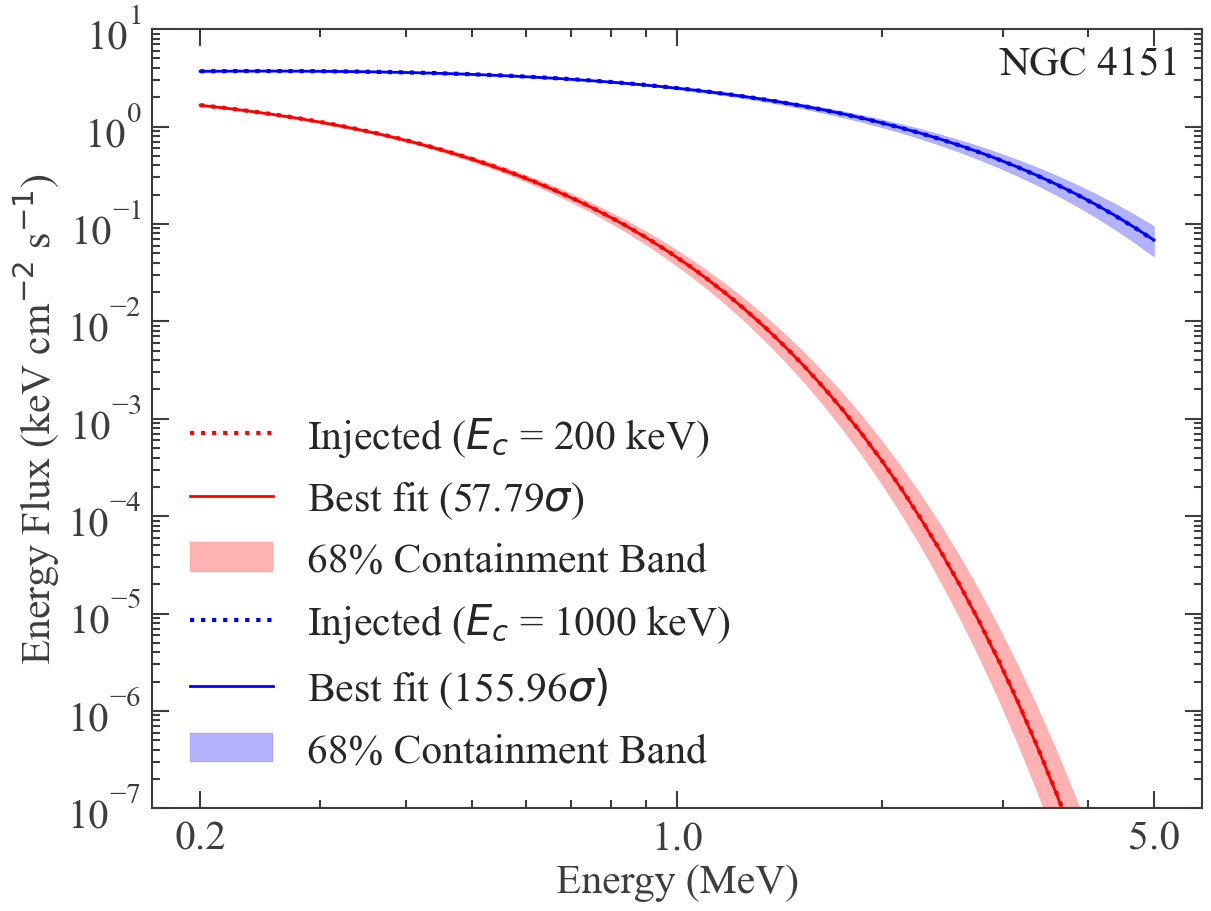

In [72]:
FONT_SIZE=30
plt.rcParams['agg.path.chunksize'] = 10000

plt.rcParams.update({'font.size': FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams.update({
    'font.weight': '550',
    'axes.titleweight': '550',
    'axes.labelweight': '550'
})

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)

ax.xaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', top='on', pad=8, labelsize=FONT_SIZE)
ax.xaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', top='on', pad=8)
ax.yaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', right='on', pad=8, labelsize=FONT_SIZE)
ax.yaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', right='on', pad=8)

ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)

Sigma = np.sqrt(TS)
Sigma_ec1000 = np.sqrt(TS_ec1000)

# # NGC 4151
text = f'NGC 4151'

ax.plot(energy, energy*energy*flux_inj, color = 'red', ls = ":", lw=3, label = "Injected ($E_c$ = 200 keV)")
ax.plot(energy, energy*energy*flux_median, color = 'red', label = f"Best fit ({Sigma:.2f}$\sigma$)")
ax.fill_between(energy, energy*energy*flux_lo, energy*energy*flux_hi, alpha = .3, color = 'red', label = "68% Containment Band")

ax.plot(energy, energy*energy*flux_inj_ec1000, color = 'blue', ls = ":", lw=3, label = "Injected ($E_c$ = 1000 keV)")
ax.plot(energy, energy*energy*flux_median_ec1000, color = 'blue', label = f"Best fit ({Sigma_ec1000:.2f}$\sigma)$")
ax.fill_between(energy, energy*energy*flux_lo_ec1000, energy*energy*flux_hi_ec1000, alpha = .3, color='blue', label = "68% Containment Band")

ax.text(
    0.98, 0.98,
    text,
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)
save_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC/Plots/NGC4151_ThModel_TH_Fit_200_1000_24Months.pdf"

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_ylim(1e-7, 10)

ax.xaxis.set_major_locator(mticker.FixedLocator([200, 1000, 5000]))
ax.xaxis.set_major_formatter(
    mticker.FixedFormatter(["0.2", "1.0", "5.0"])
)

ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.set_ylabel(r"Energy Flux (keV cm$^{-2}$ s$^{-1}$)", fontsize=FONT_SIZE)

ax.legend(fontsize=FONT_SIZE, loc='lower left', frameon=False)

plt.savefig(save_path)

## Thermal SED (COSI and BAT)

This extracts bin-by-bin SED points from the thermal joint fit. The COSI helper keeps the existing measured-energy-bin workflow, and the BAT helper repeats the same one-free-normalization method over the BAT channels used in the joint fit. In every bin the photon index is frozen to the global-fit value; `xc` is also frozen by default because a single band does not constrain the cutoff reliably. The BAT effective-area correction is fixed to the joint-fit value so the per-bin fit is driven by `K`, matching the COSI nuisance-parameter treatment used below.


In [276]:
class EnergyRangeCOSILike(COSILike):
    def __init__(self, name, dr, data, bkg, sc_orientation, em_slice, **kwargs):
        self._full_data = data.copy()
        self._full_bkg = bkg.copy()
        self._em_slice = em_slice
        self._printed_warning = False

        sliced_data = self._full_data.slice[{'Em': em_slice}].copy()
        sliced_bkg = self._full_bkg.slice[{'Em': em_slice}].copy()

        super().__init__(
            name=name,
            dr=dr,
            data=sliced_data,
            bkg=sliced_bkg,
            sc_orientation=sc_orientation,
            **kwargs,
        )

    @staticmethod
    def _hist_to_dense_array(hist):
        contents = hist.contents
        if hasattr(contents, 'todense'):
            contents = contents.todense()
        if hasattr(contents, 'value'):
            contents = contents.value
        return np.asarray(contents)

    def set_model(self, model):
        super().set_model(model)

        sliced_expected_counts = {}
        signal = None

        for name, expectation in self._expected_counts.items():
            sliced_expectation = expectation.slice[{'Em': self._em_slice}].copy()
            sliced_expected_counts[name] = sliced_expectation

            contents = self._hist_to_dense_array(sliced_expectation)
            signal = contents.copy() if signal is None else signal + contents

        self._expected_counts = sliced_expected_counts
        self._signal = signal


def make_cosi_background_parameter(dataset_name):
    return Parameter(
        f'background_{dataset_name}',
        1,
        min_value=0,
        max_value=5,
        delta=0.05,
        desc='Background parameter for cosi',
    )


def _get_single_source_name(model):
    source_names = [
        name
        for name, child in getattr(model, '_children', {}).items()
        if hasattr(child, 'spectrum')
    ]

    if len(source_names) != 1:
        raise ValueError(f'Expected one source in optimized model, found {source_names}.')

    return source_names[0]


def _get_cutoff_powerlaw_shape(global_results, source_name=None):
    optimized_model = global_results.optimized_model
    if source_name is None:
        source_name = _get_single_source_name(optimized_model)

    return optimized_model[source_name].spectrum.main.Cutoff_powerlaw, source_name


def build_thermal_sed_model(global_results, freeze_cutoff=True, source_name=None):
    best_fit_shape, source_name = _get_cutoff_powerlaw_shape(global_results, source_name=source_name)

    spectrum = Cutoff_powerlaw()
    spectrum.K.value = best_fit_shape.K.value
    spectrum.piv.value = best_fit_shape.piv.value
    spectrum.xc.value = best_fit_shape.xc.value
    spectrum.index.value = best_fit_shape.index.value

    spectrum.K.unit = best_fit_shape.K.unit
    spectrum.piv.unit = best_fit_shape.piv.unit
    spectrum.xc.unit = best_fit_shape.xc.unit

    spectrum.K.min_value = max(best_fit_shape.K.value * 1e-3, 1e-12)
    spectrum.K.max_value = best_fit_shape.K.value * 1e3
    spectrum.index.fix = True
    spectrum.xc.fix = freeze_cutoff

    source = PointSource(source_name, l=l, b=b, spectral_shape=spectrum)
    return Model(source)


def _hist_sum(hist):
    contents = hist.contents
    if hasattr(contents, 'todense'):
        contents = contents.todense()
    if hasattr(contents, 'value'):
        contents = contents.value
    return float(np.asarray(contents).sum())


def _integrate_energy_flux(shape, e_min, e_max, n_points=256):
    energy_grid = np.geomspace(e_min, e_max, n_points)
    photon_flux = np.asarray([float(shape.evaluate_at(energy)) for energy in energy_grid])
    trapezoid = getattr(np, 'trapezoid', None)
    if trapezoid is None:
        trapezoid = np.trapz
    return float(trapezoid(energy_grid * photon_flux, energy_grid))


def _extract_profile_error(errors, suffix):
    if hasattr(errors, 'index'):
        for parameter_path in errors.index:
            if str(parameter_path).endswith(suffix):
                row = errors.loc[parameter_path]
                return float(row['negative_error']), float(row['positive_error'])
        return None

    for parameter_path, interval in errors.items():
        if str(parameter_path).endswith(suffix):
            return interval
    return None


def _get_global_background_scale(global_results, default=1.0):
    try:
        results_frame = global_results.get_data_frame()
    except Exception:
        return float(default)

    for parameter_path in results_frame.index:
        if str(parameter_path).startswith('background_'):
            return float(results_frame.loc[parameter_path, 'value'])

    return float(default)


def _run_joint_likelihood_fit(joint_likelihood):
    fit_status = 'covariance'
    try:
        joint_likelihood.fit(quiet=True)
    except Exception as exc:
        fit_status = f'no-covariance fallback ({type(exc).__name__})'
        joint_likelihood.fit(quiet=True, compute_covariance=False)
    return fit_status


def _hits_lower_bound(value, lower_bound):
    if lower_bound is None or not np.isfinite(lower_bound):
        return False

    atol = max(1e-18, abs(float(lower_bound)) * 1e-6)
    return bool(np.isclose(float(value), float(lower_bound), rtol=1e-3, atol=atol))


def _interpolate_profile_crossing(x1, y1, x2, y2, target):
    if np.isclose(y1, y2):
        return float(0.5 * (x1 + x2))

    fraction = float((target - y1) / (y2 - y1))
    fraction = float(np.clip(fraction, 0.0, 1.0))

    if x1 > 0 and x2 > 0:
        return float(np.exp(np.log(x1) + fraction * (np.log(x2) - np.log(x1))))

    return float(x1 + fraction * (x2 - x1))


def _find_profile_crossing(x_values, delta_ts, threshold, side):
    if len(x_values) == 0:
        return None

    minimum_index = int(np.nanargmin(delta_ts))

    if side == 'left':
        for index in range(minimum_index - 1, -1, -1):
            y1 = float(delta_ts[index])
            y2 = float(delta_ts[index + 1])
            if np.isnan(y1) or np.isnan(y2):
                continue
            if np.isclose(y1, threshold):
                return float(x_values[index])
            if (y1 - threshold) * (y2 - threshold) <= 0:
                return _interpolate_profile_crossing(
                    float(x_values[index]),
                    y1,
                    float(x_values[index + 1]),
                    y2,
                    threshold,
                )
        return None

    for index in range(minimum_index, len(x_values) - 1):
        y1 = float(delta_ts[index])
        y2 = float(delta_ts[index + 1])
        if np.isnan(y1) or np.isnan(y2):
            continue
        if np.isclose(y2, threshold):
            return float(x_values[index + 1])
        if (y1 - threshold) * (y2 - threshold) <= 0:
            return _interpolate_profile_crossing(
                float(x_values[index]),
                y1,
                float(x_values[index + 1]),
                y2,
                threshold,
            )

    return None


def _manual_k_profile_interval(
    joint_likelihood,
    parameter_path,
    center_value,
    lower_bound,
    upper_bound,
    n_steps=61,
    target_delta_ts=1.0,
    max_expansions=12,
    scan_expand_factor=1e2,
):
    if center_value <= 0:
        raise ValueError('Manual K profiling requires a positive best-fit normalization.')

    tiny_positive = float(np.finfo(float).tiny)
    scan_min = max(float(lower_bound), tiny_positive)
    scan_max = float(upper_bound) if np.isfinite(upper_bound) else float(center_value) * 1e6

    if not np.isfinite(scan_max) or scan_max <= scan_min:
        raise ValueError('Invalid K scan bounds for manual profiling.')

    import matplotlib.pyplot as plt

    left_crossing = None
    right_crossing = None

    for _ in range(max_expansions + 1):
        x_values, _, profile_values, profile_figure = joint_likelihood.get_contours(
            parameter_path,
            param_1_minimum=float(scan_min),
            param_1_maximum=float(scan_max),
            param_1_n_steps=int(n_steps),
            progress=False,
            log=(True,),
        )
        plt.close(profile_figure)

        x_values = np.asarray(x_values, dtype=float)
        profile_values = np.asarray(profile_values, dtype=float)
        delta_ts = 2.0 * (profile_values - np.nanmin(profile_values))
        minimum_index = int(np.nanargmin(delta_ts))

        left_crossing = _find_profile_crossing(x_values, delta_ts, target_delta_ts, 'left')
        right_crossing = _find_profile_crossing(x_values, delta_ts, target_delta_ts, 'right')

        if left_crossing is not None and right_crossing is not None:
            status = f'manual K profile ok ({len(x_values)} points, {scan_min:.3e}-{scan_max:.3e})'
            return float(left_crossing), float(right_crossing), status

        expanded = False

        if left_crossing is None and minimum_index > 0 and delta_ts[0] < target_delta_ts and scan_min > lower_bound:
            new_scan_min = max(float(lower_bound), float(scan_min) / scan_expand_factor)
            if new_scan_min < scan_min:
                scan_min = new_scan_min
                expanded = True

        if right_crossing is None and minimum_index < (len(x_values) - 1) and delta_ts[-1] < target_delta_ts and scan_max < upper_bound:
            new_scan_max = min(float(upper_bound), float(scan_max) * scan_expand_factor)
            if new_scan_max > scan_max:
                scan_max = new_scan_max
                expanded = True

        if not expanded:
            break

    status = f'manual K profile incomplete ({len(x_values)} points, {scan_min:.3e}-{scan_max:.3e})'
    return left_crossing, right_crossing, status


def fit_thermal_cosi_sed(
    global_results,
    data_hist,
    bkg_hist,
    dr_path,
    sc_orientation,
    n_sed_bins=5,
    freeze_cutoff=True,
    freeze_background=False,
    background_scale_value=None,
    minuit_ftol=None,
    error_estimation='minos_then_manual',
    manual_k_profile_points=61,
    manual_one_sided_mode='upper_limit',
    relax_k_lower_bound=True,
    energy_min_keV=200,
    energy_max_keV=5000,
    scan_expand_factor=1e2,
):
    threeML_config.point_source.integrate_flux_method = 'trapz'

    em_edges = data_hist.axes['Em'].edges.to_value(u.keV)
    native_em_bins = np.flatnonzero(
        (em_edges[:-1] >= energy_min_keV) & (em_edges[1:] <= energy_max_keV)
    )

    if len(native_em_bins) == 0:
        raise ValueError(
            f'No native Em bins are fully contained in {energy_min_keV}-{energy_max_keV} keV.'
        )

    def _split_last_group_remainder(arr, n_groups):
        arr = np.asarray(arr)
        if len(arr) < n_groups:
            raise ValueError(f"Need at least {n_groups} native bins, got {len(arr)}.")

        sizes = [1] * (n_groups - 1)
        sizes.append(len(arr) - (n_groups - 1))

        groups = []
        start = 0
        for size in sizes:
            groups.append(arr[start:start + size])
            start += size

        return groups

    grouped_bins = _split_last_group_remainder(native_em_bins, n_sed_bins)

    sed_rows = []
    best_fit_shape, source_name = _get_cutoff_powerlaw_shape(global_results)
    frozen_index = best_fit_shape.index.value
    frozen_cutoff = best_fit_shape.xc.value
    global_k = float(best_fit_shape.K.value)
    global_background_scale = _get_global_background_scale(global_results, default=1.0)

    if background_scale_value is not None:
        background_scale_value = float(background_scale_value)

    for sed_bin_index, group in enumerate(grouped_bins, start=1):
        em_slice = slice(int(group[0]), int(group[-1]) + 1)
        e_min = float(em_edges[group[0]])
        e_max = float(em_edges[group[-1] + 1])
        e_ref = float(np.sqrt(e_min * e_max))
        data_counts = _hist_sum(data_hist.slice[{'Em': em_slice}])
        background_counts = _hist_sum(bkg_hist.slice[{'Em': em_slice}])

        dataset_name = f'cosi_sed_bin_{sed_bin_index}'

        bin_cosi = EnergyRangeCOSILike(
            name=dataset_name,
            dr=dr_path,
            data=data_hist,
            bkg=bkg_hist,
            sc_orientation=sc_orientation,
            em_slice=em_slice,
            nuisance_param=make_cosi_background_parameter(dataset_name),
            earth_occ=True,
        )

        background_parameter = bin_cosi.nuisance_parameters[f'background_{dataset_name}']

        if freeze_background:
            if background_scale_value is None:
                background_parameter.value = global_background_scale
            else:
                background_parameter.value = background_scale_value
            background_parameter.fix = True
        else:
            background_parameter.fix = False
            if background_scale_value is not None:
                background_parameter.value = background_scale_value

        bin_model = build_thermal_sed_model(global_results, freeze_cutoff=freeze_cutoff, source_name=source_name)
        bin_like = JointLikelihood(bin_model, DataList(bin_cosi), verbose=False)

        if minuit_ftol is not None:
            bin_minuit = LocalMinimization('minuit')
            bin_minuit.setup(ftol=float(minuit_ftol))
            bin_like.set_minimizer(bin_minuit)

        # threeML can reject every covariance sample in weak bins and then crash while building the summary table.
        fit_status = _run_joint_likelihood_fit(bin_like)

        bin_results = bin_like.results
        fit_shape = bin_results.optimized_model[source_name].spectrum.main.Cutoff_powerlaw
        k_value = float(fit_shape.K.value)
        k_min = float(fit_shape.K.min_value) if fit_shape.K.min_value is not None else 0.0
        k_max = float(fit_shape.K.max_value) if fit_shape.K.max_value is not None else np.inf
        k_lower_bound_relaxed = False

        if relax_k_lower_bound and _hits_lower_bound(k_value, k_min):
            relaxed_k_min = max(k_min * 1e-2, 1e-18)
            if relaxed_k_min < k_min:
                bin_model[source_name].spectrum.main.Cutoff_powerlaw.K.min_value = relaxed_k_min
                retry_status = _run_joint_likelihood_fit(bin_like)
                fit_status = f'{fit_status}; relaxed K min to {relaxed_k_min:.3e}; retry={retry_status}'
                bin_results = bin_like.results
                fit_shape = bin_results.optimized_model[source_name].spectrum.main.Cutoff_powerlaw
                k_value = float(fit_shape.K.value)
                k_min = float(fit_shape.K.min_value) if fit_shape.K.min_value is not None else 0.0
                k_max = float(fit_shape.K.max_value) if fit_shape.K.max_value is not None else np.inf
                k_lower_bound_relaxed = True

        k_lo = k_value
        k_hi = k_value
        profile_error_status = 'not available'
        error_source = 'profile'
        has_two_sided_error = False

        run_manual_profile = error_estimation == 'manual_profile'

        if error_estimation in ('minos', 'minos_then_manual'):
            try:
                profile_errors = bin_like.get_errors(quiet=True)
                k_errors = _extract_profile_error(profile_errors, '.K')
                if k_errors is not None:
                    k_lo = max(k_value + float(k_errors[0]), k_min)
                    k_hi = min(k_value + float(k_errors[1]), k_max)
                    profile_error_status = 'ok'
                    error_source = 'profile'
                    has_two_sided_error = bool(np.isfinite(k_lo) and np.isfinite(k_hi) and (k_hi > k_lo))
                    if error_estimation == 'minos_then_manual' and not has_two_sided_error:
                        run_manual_profile = True
                else:
                    profile_error_status = 'K profile error unavailable'
                    if error_estimation == 'minos_then_manual':
                        run_manual_profile = True
            except Exception as exc:
                profile_error_status = f'{type(exc).__name__}: {exc}'
                error_source = 'profile failed'

                if not _hits_lower_bound(k_value, k_min):
                    try:
                        covariance_errors = bin_results.get_data_frame(error_type='covariance')
                        k_cov_errors = _extract_profile_error(covariance_errors, '.K')
                        if k_cov_errors is not None:
                            cov_lo = max(k_value + float(k_cov_errors[0]), k_min)
                            cov_hi = min(k_value + float(k_cov_errors[1]), k_max)
                            if np.isfinite(cov_lo) and np.isfinite(cov_hi) and (cov_hi > cov_lo):
                                k_lo = cov_lo
                                k_hi = cov_hi
                                profile_error_status = f'covariance fallback ({type(exc).__name__})'
                                error_source = 'covariance fallback'
                                has_two_sided_error = True
                    except Exception:
                        pass

                if error_estimation == 'minos_then_manual' and not has_two_sided_error:
                    run_manual_profile = True

        if run_manual_profile:
            profile_k_max = max(k_max, global_k * 1e6, k_value * 1e6)
            if np.isfinite(profile_k_max) and profile_k_max > k_max:
                bin_model[source_name].spectrum.main.Cutoff_powerlaw.K.max_value = profile_k_max
                k_max = float(bin_model[source_name].spectrum.main.Cutoff_powerlaw.K.max_value)

            k_path = f'{source_name}.spectrum.main.Cutoff_powerlaw.K'
            try:
                profile_k_lo, profile_k_hi, manual_status = _manual_k_profile_interval(
                    bin_like,
                    k_path,
                    k_value,
                    k_min,
                    k_max,
                    n_steps=manual_k_profile_points,
                    max_expansions=12,
                    scan_expand_factor=scan_expand_factor,
                )

                if profile_k_lo is not None and profile_k_hi is not None and profile_k_hi > profile_k_lo:
                    k_lo = max(float(profile_k_lo), k_min)
                    k_hi = min(float(profile_k_hi), k_max)
                    profile_error_status = manual_status
                    error_source = 'manual profile'
                    has_two_sided_error = True
                elif profile_k_hi is not None:
                    k_hi = min(float(profile_k_hi), k_max)
                    if manual_one_sided_mode == 'lower_bound_interval':
                        k_lo = k_min
                        profile_error_status = manual_status.replace('incomplete', 'lower-bound interval')
                        error_source = 'manual lower-bound interval'
                        has_two_sided_error = True
                    else:
                        k_lo = k_value
                        profile_error_status = manual_status.replace('incomplete', 'upper limit')
                        error_source = 'manual upper limit'
                else:
                    profile_error_status = manual_status
                    error_source = 'manual profile incomplete'
            except Exception as exc:
                profile_error_status = f'manual K profile failed ({type(exc).__name__}: {exc})'
                error_source = 'manual profile failed'

        scale_lo = k_lo / k_value if k_value > 0 else 1.0
        scale_hi = k_hi / k_value if k_value > 0 else 1.0
        integrated_flux = _integrate_energy_flux(fit_shape, e_min, e_max)
        sed_flux = float(e_ref**2 * fit_shape.evaluate_at(e_ref))
        background_scale = float(bin_cosi.nuisance_parameters[f'background_{dataset_name}'].value)
        background_is_fixed = bool(background_parameter.fix)
        hit_parameter_bound = bool(np.isclose(k_value, k_min) or (np.isfinite(k_max) and np.isclose(k_value, k_max)))
        is_upper_limit = bool(
            error_source == 'manual upper limit'
            or ((not has_two_sided_error) and _hits_lower_bound(k_value, k_min))
        )

        sed_rows.append(
            {
                'bin_index': sed_bin_index,
                'e_min_keV': e_min,
                'e_max_keV': e_max,
                'e_ref_keV': e_ref,
                'bin_energy_flux_keV_cm2_s': integrated_flux,
                'bin_energy_flux_lo_keV_cm2_s': integrated_flux * scale_lo,
                'bin_energy_flux_hi_keV_cm2_s': integrated_flux * scale_hi,
                'sed_keV_cm2_s': sed_flux,
                'sed_lo_keV_cm2_s': sed_flux * scale_lo,
                'sed_hi_keV_cm2_s': sed_flux * scale_hi,
                'source_K': k_value,
                'source_K_lo': k_lo,
                'source_K_hi': k_hi,
                'source_K_over_global': k_value / global_k if global_k > 0 else np.nan,
                'background_scale': background_scale,
                'background_scale_reference': (
                    global_background_scale if background_scale_value is None else background_scale_value
                ),
                'background_requested_fixed': freeze_background,
                'background_scale_fixed': background_is_fixed,
                'background_released_for_retry': False,
                'data_counts': data_counts,
                'background_counts': background_counts,
                'excess_counts': data_counts - background_counts,
                'fit_status': fit_status,
                'profile_error_status': profile_error_status,
                'error_source': error_source,
                'minuit_ftol': minuit_ftol,
                'error_estimation': error_estimation,
                'manual_one_sided_mode': manual_one_sided_mode,
                'k_lower_bound_relaxed': k_lower_bound_relaxed,
                'hit_parameter_bound': hit_parameter_bound,
                'is_upper_limit': is_upper_limit,
                'frozen_index': frozen_index,
                'frozen_cutoff_keV': frozen_cutoff,
            }
        )

    return pd.DataFrame(sed_rows)


def _get_effective_area_scale(global_results, plugin_name='BAT', default=1.0):
    try:
        results_frame = global_results.get_data_frame()
    except Exception:
        return float(default)

    candidates = [f'cons_{plugin_name}']
    for parameter_path in results_frame.index:
        parameter_name = str(parameter_path).split('.')[-1]
        if parameter_name in candidates or parameter_name.startswith(f'cons_{plugin_name}'):
            return float(results_frame.loc[parameter_path, 'value'])

    return float(default)


def _get_ogip_active_channel_bins(observation_path, response_path, active_range):
    probe = OGIPLike(
        '__bat_sed_probe__',
        observation=observation_path,
        response=response_path,
        verbose=False,
    )
    probe.set_active_measurements(active_range)

    active_channel_indices = np.flatnonzero(np.asarray(probe.mask, dtype=bool))
    e_min_active, e_max_active = probe.energy_boundaries

    if len(active_channel_indices) == 0:
        raise ValueError(f'No BAT channels selected by active range {active_range!r}.')

    return [
        {
            'channel_index': int(channel_index),
            'channel_number': int(channel_index + 1),
            'e_min_keV': float(e_min),
            'e_max_keV': float(e_max),
        }
        for channel_index, e_min, e_max in zip(active_channel_indices, e_min_active, e_max_active)
    ]


def _select_single_ogip_channel(plugin, channel_index):
    channel_mask = np.zeros_like(np.asarray(plugin.mask, dtype=bool))
    channel_mask[int(channel_index)] = True
    plugin._mask = channel_mask
    plugin._apply_mask_to_original_vectors()


def fit_thermal_bat_sed(
    global_results,
    observation_path,
    response_path,
    active_range='40-200',
    freeze_cutoff=True,
    freeze_effective_area=True,
    effective_area_value=None,
    minuit_ftol=1e-2,
    error_estimation='minos_then_manual',
    manual_k_profile_points=201,
    manual_one_sided_mode='lower_bound_interval',
    scan_expand_factor=1e3,
):
    threeML_config.point_source.integrate_flux_method = 'trapz'

    bat_bins = _get_ogip_active_channel_bins(observation_path, response_path, active_range)
    sed_rows = []
    best_fit_shape, source_name = _get_cutoff_powerlaw_shape(global_results)
    frozen_index = best_fit_shape.index.value
    frozen_cutoff = best_fit_shape.xc.value
    global_k = float(best_fit_shape.K.value)
    global_effective_area_scale = _get_effective_area_scale(global_results, plugin_name='BAT', default=1.0)

    if effective_area_value is not None:
        effective_area_value = float(effective_area_value)

    for sed_bin_index, bat_bin in enumerate(bat_bins, start=1):
        e_min = bat_bin['e_min_keV']
        e_max = bat_bin['e_max_keV']
        e_ref = float(np.sqrt(e_min * e_max))
        channel_index = bat_bin['channel_index']
        channel_number = bat_bin['channel_number']
        dataset_name = f'bat_sed_bin_{sed_bin_index}'

        bin_bat = OGIPLike(
            dataset_name,
            observation=observation_path,
            response=response_path,
            verbose=False,
        )
        bin_bat.set_active_measurements(active_range)
        _select_single_ogip_channel(bin_bat, channel_index)
        bin_bat.use_effective_area_correction(0.2, 1.8)

        area_parameter = bin_bat.nuisance_parameters[f'cons_{dataset_name}']
        area_reference = global_effective_area_scale if effective_area_value is None else effective_area_value

        if freeze_effective_area:
            bin_bat.fix_effective_area_correction(area_reference)
        else:
            area_parameter.value = area_reference
            area_parameter.fix = False

        bin_model = build_thermal_sed_model(global_results, freeze_cutoff=freeze_cutoff, source_name=source_name)
        bin_like = JointLikelihood(bin_model, DataList(bin_bat), verbose=False)

        if minuit_ftol is not None:
            bin_minuit = LocalMinimization('minuit')
            bin_minuit.setup(ftol=float(minuit_ftol))
            bin_like.set_minimizer(bin_minuit)

        fit_status = _run_joint_likelihood_fit(bin_like)

        bin_results = bin_like.results
        fit_shape = bin_results.optimized_model[source_name].spectrum.main.Cutoff_powerlaw
        k_value = float(fit_shape.K.value)
        k_min = float(fit_shape.K.min_value) if fit_shape.K.min_value is not None else 0.0
        k_max = float(fit_shape.K.max_value) if fit_shape.K.max_value is not None else np.inf
        k_lower_bound_relaxed = False

        k_lo = k_value
        k_hi = k_value
        profile_error_status = 'not available'
        error_source = 'profile'
        has_two_sided_error = False

        run_manual_profile = error_estimation == 'manual_profile'

        if error_estimation in ('minos', 'minos_then_manual'):
            try:
                profile_errors = bin_like.get_errors(quiet=True)
                k_errors = _extract_profile_error(profile_errors, '.K')
                if k_errors is not None:
                    k_lo = max(k_value + float(k_errors[0]), k_min)
                    k_hi = min(k_value + float(k_errors[1]), k_max)
                    profile_error_status = 'ok'
                    error_source = 'profile'
                    has_two_sided_error = bool(np.isfinite(k_lo) and np.isfinite(k_hi) and (k_hi > k_lo))
                    if error_estimation == 'minos_then_manual' and not has_two_sided_error:
                        run_manual_profile = True
                else:
                    profile_error_status = 'K profile error unavailable'
                    if error_estimation == 'minos_then_manual':
                        run_manual_profile = True
            except Exception as exc:
                profile_error_status = f'{type(exc).__name__}: {exc}'
                error_source = 'profile failed'

                if not _hits_lower_bound(k_value, k_min):
                    try:
                        covariance_errors = bin_results.get_data_frame(error_type='covariance')
                        k_cov_errors = _extract_profile_error(covariance_errors, '.K')
                        if k_cov_errors is not None:
                            cov_lo = max(k_value + float(k_cov_errors[0]), k_min)
                            cov_hi = min(k_value + float(k_cov_errors[1]), k_max)
                            if np.isfinite(cov_lo) and np.isfinite(cov_hi) and (cov_hi > cov_lo):
                                k_lo = cov_lo
                                k_hi = cov_hi
                                profile_error_status = f'covariance fallback ({type(exc).__name__})'
                                error_source = 'covariance fallback'
                                has_two_sided_error = True
                    except Exception:
                        pass

                if error_estimation == 'minos_then_manual' and not has_two_sided_error:
                    run_manual_profile = True

        if run_manual_profile:
            profile_k_max = max(k_max, global_k * 1e6, k_value * 1e6)
            if np.isfinite(profile_k_max) and profile_k_max > k_max:
                bin_model[source_name].spectrum.main.Cutoff_powerlaw.K.max_value = profile_k_max
                k_max = float(bin_model[source_name].spectrum.main.Cutoff_powerlaw.K.max_value)

            k_path = f'{source_name}.spectrum.main.Cutoff_powerlaw.K'
            try:
                profile_k_lo, profile_k_hi, manual_status = _manual_k_profile_interval(
                    bin_like,
                    k_path,
                    k_value,
                    k_min,
                    k_max,
                    n_steps=manual_k_profile_points,
                    max_expansions=12,
                    scan_expand_factor=scan_expand_factor,
                )

                if profile_k_lo is not None and profile_k_hi is not None and profile_k_hi > profile_k_lo:
                    k_lo = max(float(profile_k_lo), k_min)
                    k_hi = min(float(profile_k_hi), k_max)
                    profile_error_status = manual_status
                    error_source = 'manual profile'
                    has_two_sided_error = True
                elif profile_k_hi is not None:
                    k_hi = min(float(profile_k_hi), k_max)
                    if manual_one_sided_mode == 'lower_bound_interval':
                        k_lo = k_min
                        profile_error_status = manual_status.replace('incomplete', 'lower-bound interval')
                        error_source = 'manual lower-bound interval'
                        has_two_sided_error = True
                    else:
                        k_lo = k_value
                        profile_error_status = manual_status.replace('incomplete', 'upper limit')
                        error_source = 'manual upper limit'
                else:
                    profile_error_status = manual_status
                    error_source = 'manual profile incomplete'
            except Exception as exc:
                profile_error_status = f'manual K profile failed ({type(exc).__name__}: {exc})'
                error_source = 'manual profile failed'

        scale_lo = k_lo / k_value if k_value > 0 else 1.0
        scale_hi = k_hi / k_value if k_value > 0 else 1.0
        integrated_flux = _integrate_energy_flux(fit_shape, e_min, e_max)
        sed_flux = float(e_ref**2 * fit_shape.evaluate_at(e_ref))
        effective_area_scale = float(area_parameter.value)
        effective_area_is_fixed = bool(area_parameter.fix)
        hit_parameter_bound = bool(np.isclose(k_value, k_min) or (np.isfinite(k_max) and np.isclose(k_value, k_max)))
        is_upper_limit = bool(
            error_source == 'manual upper limit'
            or ((not has_two_sided_error) and _hits_lower_bound(k_value, k_min))
        )
        observed_counts = float(np.asarray(bin_bat._current_observed_counts).sum())
        current_background_counts = getattr(bin_bat, '_current_background_counts', None)
        if current_background_counts is None:
            background_counts = 0.0
        else:
            background_counts = float(np.asarray(current_background_counts).sum())

        sed_rows.append(
            {
                'instrument': 'BAT',
                'bin_index': sed_bin_index,
                'channel_index': channel_index,
                'channel_number': channel_number,
                'active_range': active_range,
                'e_min_keV': e_min,
                'e_max_keV': e_max,
                'e_ref_keV': e_ref,
                'bin_energy_flux_keV_cm2_s': integrated_flux,
                'bin_energy_flux_lo_keV_cm2_s': integrated_flux * scale_lo,
                'bin_energy_flux_hi_keV_cm2_s': integrated_flux * scale_hi,
                'sed_keV_cm2_s': sed_flux,
                'sed_lo_keV_cm2_s': sed_flux * scale_lo,
                'sed_hi_keV_cm2_s': sed_flux * scale_hi,
                'source_K': k_value,
                'source_K_lo': k_lo,
                'source_K_hi': k_hi,
                'source_K_over_global': k_value / global_k if global_k > 0 else np.nan,
                'effective_area_scale': effective_area_scale,
                'effective_area_scale_reference': area_reference,
                'effective_area_requested_fixed': freeze_effective_area,
                'effective_area_scale_fixed': effective_area_is_fixed,
                'data_counts': observed_counts,
                'background_counts': background_counts,
                'excess_counts': observed_counts - background_counts,
                'fit_status': fit_status,
                'profile_error_status': profile_error_status,
                'error_source': error_source,
                'minuit_ftol': minuit_ftol,
                'error_estimation': error_estimation,
                'manual_one_sided_mode': manual_one_sided_mode,
                'k_lower_bound_relaxed': k_lower_bound_relaxed,
                'hit_parameter_bound': hit_parameter_bound,
                'is_upper_limit': is_upper_limit,
                'frozen_index': frozen_index,
                'frozen_cutoff_keV': frozen_cutoff,
            }
        )

    return pd.DataFrame(sed_rows)



In [277]:
n_thermal_sed_bins = 4

# # Manual Scan
# thermal_cosi_sed_df = fit_thermal_cosi_sed(
#     global_results=results_sed,
#     data_hist=data_sed_hist,
#     bkg_hist=bkg_sed_hist,
#     dr_path=dr,
#     sc_orientation=sc_orientation,
#     n_sed_bins=n_thermal_sed_bins,
#     freeze_cutoff=True,
#     freeze_background=False,
#     minuit_ftol=1e-3,
#     error_estimation='manual_profile',
#     manual_k_profile_points=61,
#     energy_min_keV=200,
#     energy_max_keV=5000,
# )

thermal_cosi_sed_df = fit_thermal_cosi_sed(
    global_results=results_sed,
    data_hist=data_sed_hist,
    bkg_hist=bkg_sed_hist,
    dr_path=dr,
    sc_orientation=sc_orientation,
    n_sed_bins=n_thermal_sed_bins,
    freeze_cutoff=True,
    freeze_background=False,
    minuit_ftol=1e-2,
    error_estimation='minos_then_manual',
    manual_k_profile_points=201,
    manual_one_sided_mode='lower_bound_interval',
    energy_min_keV=200,
    energy_max_keV=5000,
    scan_expand_factor=1e6,
)


display(
    thermal_cosi_sed_df[
        [
            "bin_index",
            "e_min_keV",
            "e_max_keV",
            "e_ref_keV",
            "bin_energy_flux_keV_cm2_s",
            "bin_energy_flux_lo_keV_cm2_s",
            "bin_energy_flux_hi_keV_cm2_s",
        ]
    ]
)

display(
    thermal_cosi_sed_df[
        [
            "bin_index",
            "source_K",
            "source_K_lo",
            "source_K_hi",
            "source_K_over_global",
            "background_scale",
            "background_scale_reference",
            "background_requested_fixed",
            "background_scale_fixed",
            "background_released_for_retry",
            "data_counts",
            "background_counts",
            "excess_counts",
            "fit_status",
            "profile_error_status",
            "error_source",
            "minuit_ftol",
            "error_estimation",
            "k_lower_bound_relaxed",
            "hit_parameter_bound",
            "is_upper_limit",
        ]
    ]
)

12:07:25 INFO      set the minimizer to minuit                                             ]8;id=226500;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=964241;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=803483;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=860693;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

Adding 1e-12 to each bin of the expectation to avoid log-likelihood = -inf.


12:08:35 INFO      set the minimizer to minuit                                             ]8;id=693034;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=310906;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=526100;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=921111;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

...

12:11:03 INFO      set the minimizer to minuit                                             ]8;id=680390;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=364050;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=724226;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=231934;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

Adding 1e-12 to each bin of the expectation to avoid log-likelihood = -inf.


,bin_index,e_min_keV,e_max_keV,e_ref_keV,bin_energy_flux_keV_cm2_s,bin_energy_flux_lo_keV_cm2_s,bin_energy_flux_hi_keV_cm2_s
0,1,251.189,398.107,316.227923,0.060017,5.324423e-02,0.066803
1,2,398.107,630.957,501.186989,0.027204,1.928331e-02,0.035222
2,3,630.957,1000.000,794.328018,0.007491,7.095629e-06,0.018090
3,4,1000.000,3981.070,1995.261888,0.000887,8.870729e-07,0.015743


,bin_index,source_K,source_K_lo,source_K_hi,source_K_over_global,background_scale,background_scale_reference,background_requested_fixed,background_scale_fixed,background_released_for_retry,data_counts,background_counts,excess_counts,fit_status,profile_error_status,error_source,minuit_ftol,error_estimation,k_lower_bound_relaxed,hit_parameter_bound,is_upper_limit
0,1,0.000015,1.310240e-05,0.000016,1.002135,1.000005,1.000012,False,False,False,5.273538e+06,5255451.861,18085.700532,covariance,ok,profile,0.01,minos_then_manual,False,False,False
1,2,0.000015,1.062715e-05,0.000019,1.017292,1.000005,1.000012,False,False,False,3.541292e+06,3536358.550,4933.747233,covariance,ok,profile,0.01,minos_then_manual,False,False,False
2,3,0.000016,1.473746e-08,0.000038,1.055654,1.000001,1.000012,False,False,False,2.333028e+06,2332239.039,789.149245,covariance,ok,profile,0.01,minos_then_manual,False,False,False
3,4,0.000015,1.473746e-08,0.000262,1.000000,1.000000,1.000012,False,False,False,3.663779e+06,3663718.684,60.213429,covariance,ok,profile,0.01,minos_then_manual,False,False,False


In [278]:
n_thermal_sed_bins = 6

# # Manual Scan
# thermal_cosi_sed_df_ec1000 = fit_thermal_cosi_sed(
#     global_results=results_sed_ec1000,
#     data_hist=data_sed_hist,
#     bkg_hist=bkg_sed_hist,
#     dr_path=dr,
#     sc_orientation=sc_orientation,
#     n_sed_bins=n_thermal_sed_bins,
#     freeze_cutoff=True,
#     freeze_background=False,
#     minuit_ftol=1e-3,
#     error_estimation='manual_profile',
#     manual_k_profile_points=61,
#     manual_one_sided_mode='lower_bound_interval',
#     energy_min_keV=200,
#     energy_max_keV=5000,
# )

thermal_cosi_sed_df_ec1000 = fit_thermal_cosi_sed(
    global_results=results_sed_ec1000,
    data_hist=data_sed_ec1000_hist,
    bkg_hist=bkg_sed_ec1000_hist,
    dr_path=dr,
    sc_orientation=sc_orientation,
    n_sed_bins=n_thermal_sed_bins,
    freeze_cutoff=True,
    freeze_background=True,
    minuit_ftol=1e-2,
    error_estimation='minos_then_manual',
    manual_k_profile_points=81,
    manual_one_sided_mode='lower_bound_interval',
    energy_min_keV=200,
    energy_max_keV=5000,
    scan_expand_factor=1e3,
)

display(
    thermal_cosi_sed_df_ec1000[
        [
            "bin_index",
            "e_min_keV",
            "e_max_keV",
            "e_ref_keV",
            "bin_energy_flux_keV_cm2_s",
            "bin_energy_flux_lo_keV_cm2_s",
            "bin_energy_flux_hi_keV_cm2_s",
        ]
    ]
)

display(
    thermal_cosi_sed_df_ec1000[
        [
            "bin_index",
            "source_K",
            "source_K_lo",
            "source_K_hi",
            "source_K_over_global",
            "background_scale",
            "background_scale_reference",
            "background_requested_fixed",
            "background_scale_fixed",
            "background_released_for_retry",
            "data_counts",
            "background_counts",
            "excess_counts",
            "fit_status",
            "profile_error_status",
            "error_source",
            "minuit_ftol",
            "error_estimation",
            "manual_one_sided_mode",
            "k_lower_bound_relaxed",
            "hit_parameter_bound",
            "is_upper_limit",
        ]
    ]
)

12:14:01 INFO      set the minimizer to minuit                                             ]8;id=213355;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=915156;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=535478;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=614978;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

Adding 1e-12 to each bin of the expectation to avoid log-likelihood = -inf.


12:15:09 INFO      set the minimizer to minuit                                             ]8;id=72867;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=155718;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=5883;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=159272;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

...

12:20:23 INFO      set the minimizer to minuit                                             ]8;id=63453;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=667772;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=328169;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=125853;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

Adding 1e-12 to each bin of the expectation to avoid log-likelihood = -inf.


,bin_index,e_min_keV,e_max_keV,e_ref_keV,bin_energy_flux_keV_cm2_s,bin_energy_flux_lo_keV_cm2_s,bin_energy_flux_hi_keV_cm2_s
0,1,251.189,398.107,316.227923,0.211516,0.206561,0.216474
1,2,398.107,630.957,501.186989,0.197035,0.190714,0.203363
2,3,630.957,1000.000,794.328018,0.164826,0.156031,0.173641
3,4,1000.000,1584.890,1258.924144,0.116472,0.102724,0.130238
4,5,1584.890,2511.890,1995.261723,0.063094,0.041237,0.085207
5,6,2511.890,3981.070,3162.279229,0.022653,0.000025,0.069010


,bin_index,source_K,source_K_lo,source_K_hi,source_K_over_global,background_scale,background_scale_reference,background_requested_fixed,background_scale_fixed,background_released_for_retry,data_counts,background_counts,excess_counts,fit_status,profile_error_status,error_source,minuit_ftol,error_estimation,manual_one_sided_mode,k_lower_bound_relaxed,hit_parameter_bound,is_upper_limit
0,1,0.000014,1.363524e-05,0.000014,1.002667,1.000008,1.000008,True,True,False,5.325909e+06,5255451.861,70456.845882,covariance,ok,profile,0.01,minos_then_manual,lower_bound_interval,False,False,False
1,2,0.000014,1.344989e-05,0.000014,0.997880,1.000008,1.000008,True,True,False,3.575269e+06,3536358.550,38910.235249,covariance,ok,profile,0.01,minos_then_manual,lower_bound_interval,False,False,False
2,3,0.000014,1.304910e-05,0.000015,0.989912,1.000008,1.000008,True,True,False,2.350507e+06,2332239.039,18267.785976,covariance,ok,profile,0.01,minos_then_manual,lower_bound_interval,False,False,False
3,4,0.000014,1.199874e-05,0.000015,0.976977,1.000008,1.000008,True,True,False,1.880544e+06,1873449.861,7094.163520,covariance,ok,profile,0.01,minos_then_manual,lower_bound_interval,False,False,False
4,5,0.000013,8.681649e-06,0.000018,0.953901,1.000008,1.000008,True,True,False,1.261330e+06,1259337.719,1992.619231,covariance,ok,profile,0.01,minos_then_manual,lower_bound_interval,False,False,False
5,6,0.000013,1.392519e-08,0.000039,0.915477,1.000008,1.000008,True,True,False,5.311614e+05,530931.104,230.271581,covariance,ok,profile,0.01,minos_then_manual,lower_bound_interval,False,False,False


In [279]:
thermal_bat_sed_df = fit_thermal_bat_sed(
    global_results=results_sed,
    observation_path=bat_pha_ec200,
    response_path=bat_rsp_ec200,
    active_range='40-200',
    freeze_cutoff=True,
    freeze_effective_area=True,
    minuit_ftol=1e-2,
    error_estimation='minos_then_manual',
    manual_k_profile_points=201,
    manual_one_sided_mode='lower_bound_interval',
    scan_expand_factor=1e3,
)


display(
    thermal_bat_sed_df[
        [
            'instrument',
            'bin_index',
            'channel_number',
            'e_min_keV',
            'e_max_keV',
            'e_ref_keV',
            'bin_energy_flux_keV_cm2_s',
            'bin_energy_flux_lo_keV_cm2_s',
            'bin_energy_flux_hi_keV_cm2_s',
            'sed_keV_cm2_s',
            'sed_lo_keV_cm2_s',
            'sed_hi_keV_cm2_s',
            'source_K',
            'source_K_lo',
            'source_K_hi',
            'source_K_over_global',
            'effective_area_scale',
            'effective_area_scale_reference',
            'effective_area_scale_fixed',
            'data_counts',
            'background_counts',
            'excess_counts',
            'fit_status',
            'profile_error_status',
            'error_source',
            'is_upper_limit',
        ]
    ]
)


12:25:02 INFO      Auto-probed noise models:                                                    ]8;id=463346;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=631396;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#486\486]8;;\

         INFO      - observation: gaussian                                                      ]8;id=141153;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=869397;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#487\487]8;;\

         INFO      - background: None                                                           ]8;id=534692;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=385896;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#488\488]8;;\

         INFO      Range 40-200 translates to channels 3-8                                     ]8;id=643308;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=248136;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#1237\1237]8;;\

         INFO      Auto-probed noise models:                                                    ]8;id=981470;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=296855;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#486\486]8;;\

...

         INFO      Range 40-200 translates to channels 3-8                                     ]8;id=468675;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=441923;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#1237\1237]8;;\

         INFO      bat_sed_bin_5 is using effective area correction (between 0.2 and 1.8)      ]8;id=241066;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=358469;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#2224\2224]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=735874;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=347356;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=944368;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=993069;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

,instrument,bin_index,channel_number,e_min_keV,e_max_keV,e_ref_keV,bin_energy_flux_keV_cm2_s,bin_energy_flux_lo_keV_cm2_s,bin_energy_flux_hi_keV_cm2_s,sed_keV_cm2_s,sed_lo_keV_cm2_s,sed_hi_keV_cm2_s,source_K,source_K_lo,source_K_hi,source_K_over_global,effective_area_scale,effective_area_scale_reference,effective_area_scale_fixed,data_counts,background_counts,excess_counts,fit_status,profile_error_status,error_source,is_upper_limit
0,BAT,1,4,35.0,50.0,41.833001,0.106561,0.106151,0.106972,0.299100,0.297948,0.300252,0.000015,0.000015,0.000015,0.998942,0.501184,0.501184,True,41773.367188,0.0,41773.367188,covariance,ok,profile,False
1,BAT,2,5,50.0,75.0,61.237244,0.122913,0.122336,0.123490,0.303803,0.302376,0.305230,0.000015,0.000015,0.000015,1.003738,0.501184,0.501184,True,36163.062500,0.0,36163.062500,covariance,ok,profile,False
2,BAT,3,6,75.0,100.0,86.602540,0.083519,0.082783,0.084255,0.290745,0.288181,0.293307,0.000015,0.000014,0.000015,0.990223,0.501184,0.501184,True,13301.826172,0.0,13301.826172,covariance,ok,profile,False
3,BAT,4,7,100.0,150.0,122.474487,0.110439,0.108527,0.112351,0.273343,0.268613,0.278077,0.000015,0.000015,0.000015,1.013670,0.501184,0.501184,True,6795.433105,0.0,6795.433105,covariance,ok,profile,False
4,BAT,5,8,150.0,195.0,171.026314,0.056851,0.051411,0.062290,0.217019,0.196253,0.237781,0.000014,0.000013,0.000015,0.939630,0.501184,0.501184,True,833.375610,0.0,833.375610,covariance,ok,profile,False


In [280]:
thermal_bat_sed_df_ec1000 = fit_thermal_bat_sed(
    global_results=results_sed_ec1000,
    observation_path=bat_pha_ec1000,
    response_path=bat_rsp_ec1000,
    active_range='40-200',
    freeze_cutoff=True,
    freeze_effective_area=True,
    minuit_ftol=1e-2,
    error_estimation='minos_then_manual',
    manual_k_profile_points=201,
    manual_one_sided_mode='lower_bound_interval',
    scan_expand_factor=1e3,
)


display(
    thermal_bat_sed_df_ec1000[
        [
            'instrument',
            'bin_index',
            'channel_number',
            'e_min_keV',
            'e_max_keV',
            'e_ref_keV',
            'bin_energy_flux_keV_cm2_s',
            'bin_energy_flux_lo_keV_cm2_s',
            'bin_energy_flux_hi_keV_cm2_s',
            'sed_keV_cm2_s',
            'sed_lo_keV_cm2_s',
            'sed_hi_keV_cm2_s',
            'source_K',
            'source_K_lo',
            'source_K_hi',
            'source_K_over_global',
            'effective_area_scale',
            'effective_area_scale_reference',
            'effective_area_scale_fixed',
            'data_counts',
            'background_counts',
            'excess_counts',
            'fit_status',
            'profile_error_status',
            'error_source',
            'is_upper_limit',
        ]
    ]
)


12:25:06 INFO      Auto-probed noise models:                                                    ]8;id=340865;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=970856;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#486\486]8;;\

         INFO      - observation: gaussian                                                      ]8;id=714555;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=536666;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#487\487]8;;\

         INFO      - background: None                                                           ]8;id=613925;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=444321;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#488\488]8;;\

         INFO      Range 40-200 translates to channels 3-8                                     ]8;id=245904;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=676250;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#1237\1237]8;;\

         INFO      Auto-probed noise models:                                                    ]8;id=124056;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=74867;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#486\486]8;;\

...

         INFO      Range 40-200 translates to channels 3-8                                     ]8;id=105728;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=675658;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#1237\1237]8;;\

         INFO      bat_sed_bin_5 is using effective area correction (between 0.2 and 1.8)      ]8;id=687318;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=699754;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#2224\2224]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=152962;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=615988;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=154457;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=1295;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

,instrument,bin_index,channel_number,e_min_keV,e_max_keV,e_ref_keV,bin_energy_flux_keV_cm2_s,bin_energy_flux_lo_keV_cm2_s,bin_energy_flux_hi_keV_cm2_s,sed_keV_cm2_s,sed_lo_keV_cm2_s,sed_hi_keV_cm2_s,source_K,source_K_lo,source_K_hi,source_K_over_global,effective_area_scale,effective_area_scale_reference,effective_area_scale_fixed,data_counts,background_counts,excess_counts,fit_status,profile_error_status,error_source,is_upper_limit
0,BAT,1,4,35.0,50.0,41.833001,0.129408,0.129357,0.129460,0.362814,0.362671,0.362958,0.000014,0.000014,0.000014,0.999990,0.941322,0.941322,True,140244.322812,0.0,140244.322812,covariance,ok,profile,False
1,BAT,2,5,50.0,75.0,61.237244,0.158674,0.158601,0.158748,0.391403,0.391222,0.391585,0.000014,0.000014,0.000014,1.000115,0.941322,0.941322,True,130002.935455,0.0,130002.935455,covariance,ok,profile,False
2,BAT,3,6,75.0,100.0,86.602540,0.119628,0.119532,0.119724,0.415915,0.415581,0.416249,0.000014,0.000014,0.000014,0.999470,0.941322,0.941322,True,53884.945517,0.0,53884.945517,covariance,ok,profile,False
3,BAT,4,7,100.0,150.0,122.474487,0.177593,0.177329,0.177857,0.438306,0.437654,0.438957,0.000014,0.000014,0.000014,1.000701,0.941322,0.941322,True,30815.576228,0.0,30815.576228,covariance,ok,profile,False
4,BAT,5,8,150.0,195.0,171.026314,0.119280,0.118499,0.120058,0.454841,0.451866,0.457811,0.000014,0.000014,0.000014,1.001959,0.941322,0.941322,True,5037.120728,0.0,5037.120728,covariance,ok,profile,False


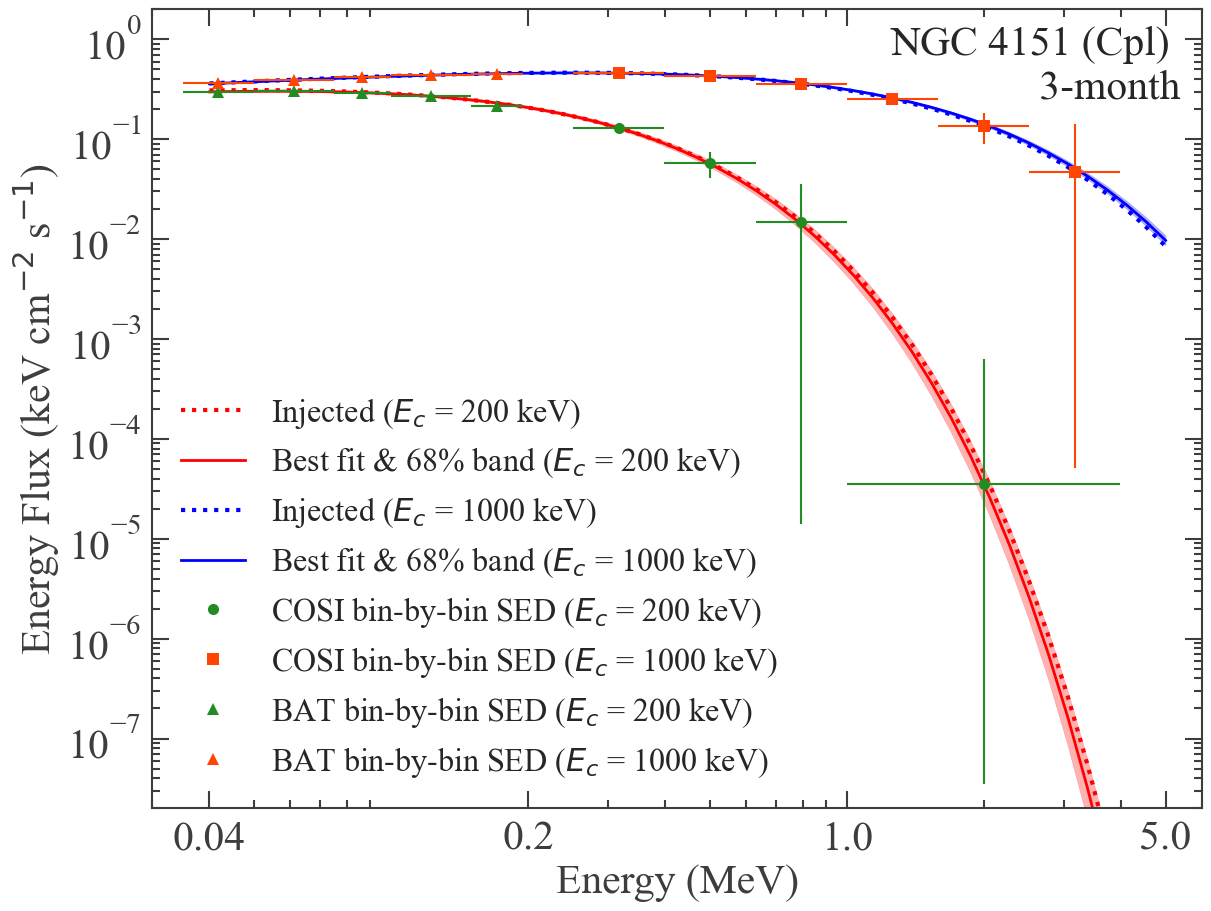

In [281]:
FONT_SIZE = 30

plt.rcParams["agg.path.chunksize"] = 10000
plt.rcParams.update({"font.size": FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.linewidth"] = 1.5
plt.rcParams.update(
    {
        "font.weight": "550",
        "axes.titleweight": "550",
        "axes.labelweight": "550",
    }
)

def _make_xerr(df):
    return np.vstack(
        [
            df["e_ref_keV"] - df["e_min_keV"],
            df["e_max_keV"] - df["e_ref_keV"],
        ]
    )


def _split_sed_detections(df):
    return (
        df.loc[~df['is_upper_limit']].copy(),
        df.loc[df['is_upper_limit']].copy(),
    )


def _plot_sed_points(ax, det, ul, marker, color, facecolor, label):
    if not det.empty:
        detection_yerr = np.vstack(
            [
                np.maximum(det['sed_keV_cm2_s'] - det['sed_lo_keV_cm2_s'], 0),
                np.maximum(det['sed_hi_keV_cm2_s'] - det['sed_keV_cm2_s'], 0),
            ]
        )

        ax.errorbar(
            det['e_ref_keV'],
            det['sed_keV_cm2_s'],
            xerr=_make_xerr(det),
            yerr=detection_yerr,
            fmt=marker,
            color=color,
            ecolor=color,
            elinewidth=1.5,
            capsize=4,
            markersize=8,
            label=label,
        )

    if not ul.empty:
        upper_y = ul['sed_hi_keV_cm2_s'].to_numpy()
        upper_yerr = np.maximum(0.5 * upper_y, np.finfo(float).tiny)

        ax.errorbar(
            ul['e_ref_keV'],
            upper_y,
            xerr=_make_xerr(ul),
            yerr=upper_yerr,
            uplims=True,
            fmt='v',
            color=color,
            ecolor=color,
            markerfacecolor=facecolor,
            markeredgecolor=color,
            markeredgewidth=1.8,
            elinewidth=2.4,
            capsize=6,
            markersize=11,
            barsabove=True,
            zorder=6,
            label='_nolegend_',
        )


n_cosi_sed_bins_200 = len(thermal_cosi_sed_df)
n_cosi_sed_bins_1000 = len(thermal_cosi_sed_df_ec1000)
n_bat_sed_bins_200 = len(thermal_bat_sed_df)
n_bat_sed_bins_1000 = len(thermal_bat_sed_df_ec1000)

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)

ax.xaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', top='on', pad=8, labelsize=FONT_SIZE)
ax.xaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', top='on', pad=8)
ax.yaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', right='on', pad=8, labelsize=FONT_SIZE)
ax.yaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', right='on', pad=8)

ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)

det_cosi_200, ul_cosi_200 = _split_sed_detections(thermal_cosi_sed_df)
det_cosi_1000, ul_cosi_1000 = _split_sed_detections(thermal_cosi_sed_df_ec1000)
det_bat_200, ul_bat_200 = _split_sed_detections(thermal_bat_sed_df)
det_bat_1000, ul_bat_1000 = _split_sed_detections(thermal_bat_sed_df_ec1000)

ax.plot(
    energy,
    energy * energy * flux_inj,
    color='red',
    ls=':',
    lw=3,
    label='Injected thermal model ($E_{c}$ = 200 keV)',
)
ax.plot(
    energy,
    energy * energy * flux_median,
    color='red',
    lw=2,
    label='Global joint fit ($E_{c}$ = 200 keV)',
)
ax.fill_between(
    energy,
    energy * energy * flux_lo,
    energy * energy * flux_hi,
    alpha=0.3,
    color='red',
)

ax.plot(
    energy,
    energy * energy * flux_inj_ec1000,
    color='blue',
    ls=':',
    lw=3,
    label='Injected thermal model ($E_{c}$ = 1000 keV)',
)
ax.plot(
    energy,
    energy * energy * flux_median_ec1000,
    color='blue',
    lw=2,
    label='Global joint fit ($E_{c}$ = 1000 keV)',
)
ax.fill_between(
    energy,
    energy * energy * flux_lo_ec1000,
    energy * energy * flux_hi_ec1000,
    alpha=0.3,
    color='blue',
)

_plot_sed_points(
    ax,
    det_cosi_200,
    ul_cosi_200,
    marker='o',
    color='forestgreen',
    facecolor='honeydew',
    label=f'COSI bin-by-bin SED ($E_{{c}}$ = 200 keV; {len(det_cosi_200)} detections out of {n_cosi_sed_bins_200} bins)',
)
_plot_sed_points(
    ax,
    det_cosi_1000,
    ul_cosi_1000,
    marker='s',
    color='orangered',
    facecolor='moccasin',
    label=f'COSI bin-by-bin SED ($E_{{c}}$ = 1000 keV; {len(det_cosi_1000)} detections out of {n_cosi_sed_bins_1000} bins)',
)
_plot_sed_points(
    ax,
    det_bat_200,
    ul_bat_200,
    marker='^',
    color='forestgreen',
    facecolor='honeydew',
    label=f'BAT bin-by-bin SED ($E_{{c}}$ = 200 keV; {len(det_bat_200)} detections out of {n_bat_sed_bins_200} bins)',
)
_plot_sed_points(
    ax,
    det_bat_1000,
    ul_bat_1000,
    marker='^',
    color='orangered',
    facecolor='moccasin',
    label=f'BAT bin-by-bin SED ($E_{{c}}$ = 1000 keV; {len(det_bat_1000)} detections out of {n_bat_sed_bins_1000} bins)',
)

legend_handles = [
    plt.Line2D([], [], color='red', ls=':', lw=3, label='Injected ($E_{c}$ = 200 keV)'),
    plt.Line2D([], [], color='red', lw=2, label='Best fit & 68% band ($E_{c}$ = 200 keV)'),
    plt.Line2D([], [], color='blue', ls=':', lw=3, label='Injected ($E_{c}$ = 1000 keV)'),
    plt.Line2D([], [], color='blue', lw=2, label='Best fit & 68% band ($E_{c}$ = 1000 keV)'),
]

if not det_cosi_200.empty:
    legend_handles.append(
        plt.Line2D([], [], color='forestgreen', marker='o', linestyle='None', markersize=8, label='COSI bin-by-bin SED ($E_{c}$ = 200 keV)')
    )

if not det_cosi_1000.empty:
    legend_handles.append(
        plt.Line2D([], [], color='orangered', marker='s', linestyle='None', markersize=8, label='COSI bin-by-bin SED ($E_{c}$ = 1000 keV)')
    )

if not det_bat_200.empty:
    legend_handles.append(
        plt.Line2D([], [], color='forestgreen', marker='^', linestyle='None', markersize=8, label='BAT bin-by-bin SED ($E_{c}$ = 200 keV)')
    )

if not det_bat_1000.empty:
    legend_handles.append(
        plt.Line2D([], [], color='orangered', marker='^', linestyle='None', markersize=8, label='BAT bin-by-bin SED ($E_{c}$ = 1000 keV)')
    )

ax.text(
    0.98, 0.98,
    f'NGC 4151 (Cpl) \n {exposure_4151}-month',
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(30, 6000)
ax.set_ylim(2e-8, 2)

ax.xaxis.set_major_locator(mticker.FixedLocator([40, 200, 1000, 5000]))
ax.xaxis.set_major_formatter(mticker.FixedFormatter(['0.04', '0.2', '1.0', '5.0']))

ax.set_xlabel('Energy (MeV)', fontsize=FONT_SIZE)
ax.set_ylabel(r'Energy Flux (keV cm$^{-2}$ s$^{-1}$)', fontsize=FONT_SIZE)
ax.legend(handles=legend_handles, fontsize=23, loc='lower left', frameon=False)

save_path = f'/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC/Plots/NGC4151_ThModel_TH_200_1000_{exposure_4151}Months_Joint_SED.pdf'
plt.savefig(save_path)
